# MMIA 6013 — IA Generativa y Agentes
## Universidad San Francisco de Quito (USFQ)
### Taller 01 — Foundation Models: Comparación, Decodificación y Razonamiento

* **Materia:** MMIA 6013 IA Generativa y Agentes
* **Semana:** 1 · **Sesión:** 05 (Sábado, 230 min)
* **Peso:** 25% de la nota final
* **Fecha de Entrega:** 19 de septiembre de 2026
* **Modalidad:** Individual o Parejas
* **Integrantes:** `[Nombre Estudiante 1]` (y `[Nombre Estudiante 2]`)
* **Repositorio del taller:** [GitHub - Taller 01](https://github.com/kalech7/notes/tree/main/Obsidian/posgrado/master/IA%20GENERATIVA%20Y%20AGENTES/talleres)

***

### Contexto y Objetivos del Taller

En este taller evaluamos las **cinco palancas de inferencia** sobre modelos fundacionales que actúan en tiempo de ejecución **sin modificar los pesos de la red**:
1. **Cómo se elige el token:** muestreo estocástico vs. búsqueda voraz (*greedy search*), temperatura ($T$), núcleo de probabilidad (*top-p* / *nucleus sampling*) y truncamiento fijo (*top-k*).
2. **Qué se pone en el prompt:** técnicas de prompting (*Zero-shot*, *Few-shot*, *Chain-of-Thought*).
3. **Qué forma tiene la salida:** texto libre vs. formatos estructurados (*JSON Schema estricto* con decodificación restringida).
4. **Qué cuesta:** volumen de tokens de entrada vs. tokens de salida, costos amortizados en USD/1M tokens, y presupuestos de inferencia.
5. **Cuánto piensa el modelo antes de responder:** esfuerzo de razonamiento (*test-time compute*, *thinking budget*, *reasoning tokens*).

El taller se ejecuta sobre un **problema con respuesta verificable automáticamente** a lo largo de un conjunto de casos de prueba estandarizados.

***
## 0. Preparación del Entorno y Credenciales

> [!IMPORTANT]
> **Política Estricta de Credenciales del Curso:**
> **Ninguna clave de API puede aparecer en el notebook, informe o repositorio.**
> Las claves se leen de variables de entorno del sistema o desde un archivo local `.env` (excluido en `.gitignore`).
>
> Para modelos locales (Parte 0 con `gpt2` y ranuras locales con Ollama/Transformers), **el costo es 0.00 USD y no se requiere ninguna credencial externa**.

In [2]:
import os
import sys
import time
import json
import random
from collections import defaultdict
import datetime
from typing import Any, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Backend de Jupyter: dibuja dentro del notebook y evita el aviso
# "FigureCanvasAgg is non-interactive" que emite plt.show() con backends sin ventana.
get_ipython().run_line_magic('matplotlib', 'inline')
import seaborn as sns

# Intentar cargar python-dotenv si está disponible
try:
    from dotenv import load_dotenv
except ImportError:
    def load_dotenv(*_args, **_kwargs):
        """Sustituto inerte si python-dotenv no está instalado."""
        return False
load_dotenv()

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Fijar semilla de reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Entorno inicializado correctamente.")
print(f"Timestamp de ejecución: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python: {sys.version.split()[0]}")

Entorno inicializado correctamente.
Timestamp de ejecución: 2026-09-19 11:33:14
Python: 3.12.13


In [3]:
# ---------------------------------------------------------------------------
# Estilo visual único para todas las figuras del taller.
# Criterios: la temperatura y el esfuerzo son variables ORDENADAS, así que usan
# una rampa de un solo tono (claro->oscuro), no una paleta arcoíris. Las tres
# ranuras de modelo son categorías sin orden, así que usan tonos distintos.
# Paleta verificada para daltonismo (deuteranopía/protanopía/tritanopía).
# ---------------------------------------------------------------------------

# Rampa secuencial (magnitud ordenada: temperatura, esfuerzo)
RAMPA_AZUL = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]
# Categóricas (identidad sin orden: las 3 ranuras de modelo)
SERIE = {"propietario_grande": "#2a78d6",
         "propietario_economico": "#eb6834",
         "open_weight_pequeno": "#1baf7a"}
# Tinta y cromo
TINTA, TINTA_2, MUTE = "#0b0b0b", "#52514e", "#898781"
REJILLA, BASE, SUPERFICIE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
CRITICO, BUENO = "#d03b3b", "#0ca30c"

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "savefig.facecolor": SUPERFICIE,
    "axes.edgecolor": BASE, "axes.labelcolor": TINTA_2, "axes.titlecolor": TINTA,
    "xtick.color": MUTE, "ytick.color": MUTE,
    "text.color": TINTA, "grid.color": REJILLA, "grid.linewidth": 0.8,
    "axes.grid": True, "axes.axisbelow": True, "lines.linewidth": 2.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 12, "figure.dpi": 110,
})


def limpiar(ax, eje_y=True):
    """Deja la rejilla recesiva y sólo en el eje que aporta lectura."""
    ax.grid(axis="y" if eje_y else "x", alpha=0.9)
    ax.grid(axis="x" if eje_y else "y", visible=False)
    ax.tick_params(length=0)


print("Estilo de figuras cargado.")

Estilo de figuras cargado.


***
## Cómo leer este notebook

El taller entero gira alrededor de **una sola inferencia** y de las cosas que
podemos cambiar en ella *sin tocar los pesos del modelo*. La figura siguiente
sitúa cada parte del taller en el punto de la tubería donde actúa.

Tres ideas que conviene tener claras antes de empezar, porque el resto se apoya
en ellas:

1. **El modelo no devuelve una palabra: devuelve una distribución.** En cada paso
   produce un número (un *logit*) para cada uno de los ~50 000 tokens de su
   vocabulario. Todo lo demás —temperatura, top-p, top-k— es aritmética sobre
   esos números. La Parte 0 los mira directamente.

2. **"Que un parámetro exista" y "que el parámetro haga algo" son cosas distintas.**
   Una API puede aceptar `temperature` y devolver HTTP 200 sin que cambie nada,
   porque el decodificador es voraz. La Parte 2 separa esos dos hechos midiendo,
   no leyendo documentación.

3. **La exactitud sólo significa algo si hay un verificador automático.** Por eso
   la tarea es clasificación cerrada en 4 clases: la respuesta se compara con la
   esperada sin intervención humana. Sin eso, las Partes 2 y 4 no serían puntuables.

> **Origen de los números.** Todas las cifras de este notebook provienen de
> llamadas ejecutadas en el momento de correrlo: GPT-2 en local vía
> `transformers`, `gpt-4o-mini` y `gpt-5.6-luna` contra la API de OpenAI, y
> `qwen3:1.7b` en local vía Ollama. Las ranuras sin credencial o sin servicio
> se declaran explícitamente **NO EJECUTADAS** en lugar de rellenarse con
> valores plausibles. El registro crudo de cada llamada queda en `resultados.csv`.

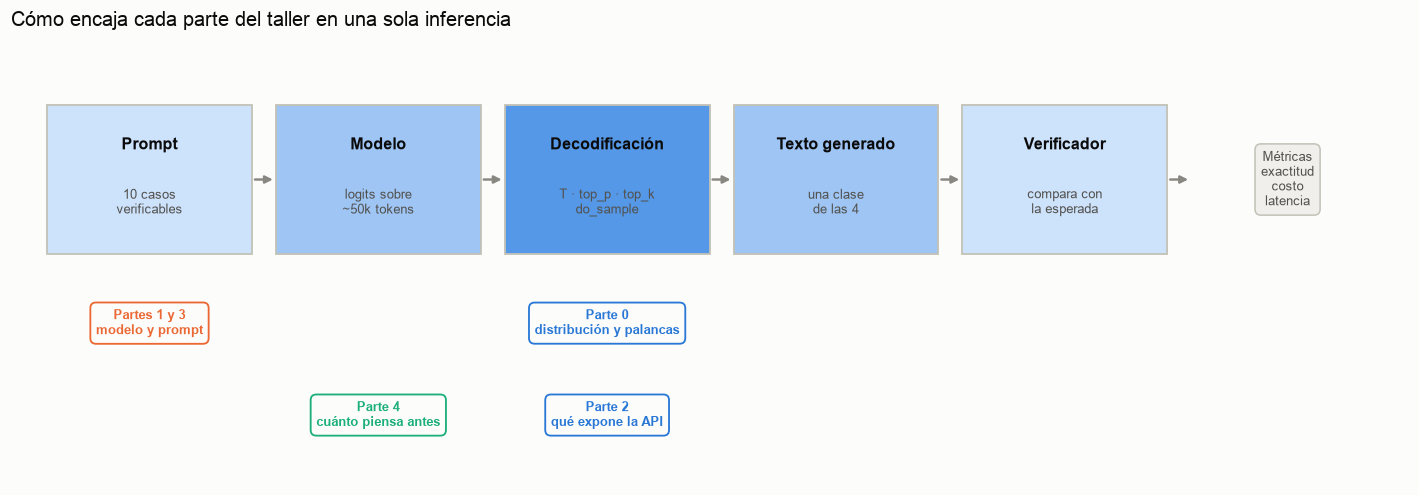

In [4]:
# Mapa conceptual: qué mide cada parte del taller y en qué punto de la tubería.

fig, ax = plt.subplots(figsize=(13, 4.6))
ax.set_xlim(0, 116); ax.set_ylim(0, 38); ax.axis("off")

etapas = [
    ("Prompt",           "10 casos\nverificables",          3, "#cde2fb"),
    ("Modelo",           "logits sobre\n~50k tokens",      22, "#9ec5f4"),
    ("Decodificación",   "T · top_p · top_k\ndo_sample",   41, "#5598e7"),
    ("Texto generado",   "una clase\nde las 4",            60, "#9ec5f4"),
    ("Verificador",      "compara con\nla esperada",       79, "#cde2fb"),
]
for titulo, sub, x, color in etapas:
    ax.add_patch(plt.Rectangle((x, 20), 17, 13, facecolor=color,
                               edgecolor=BASE, linewidth=1.2, zorder=2))
    ax.text(x + 8.5, 29.5, titulo, ha="center", va="center",
            fontsize=10.5, fontweight="bold", color=TINTA, zorder=3)
    ax.text(x + 8.5, 24.5, sub, ha="center", va="center",
            fontsize=8.5, color=TINTA_2, zorder=3)
for x in (20, 39, 58, 77, 96):
    ax.annotate("", xy=(x + 2, 26.5), xytext=(x, 26.5),
                arrowprops=dict(arrowstyle="-|>", color=MUTE, lw=1.6))

# Qué parte del taller interviene en cada punto
anclas = [
    ("Parte 0\ndistribución y palancas", 30.5, "#2a78d6"),
    ("Partes 1 y 3\nmodelo y prompt",    11.5, "#eb6834"),
    ("Parte 2\nqué expone la API",       49.5, "#2a78d6"),
    ("Parte 4\ncuánto piensa antes",     30.5, "#1baf7a"),
]
posiciones = [(41 + 8.5, 14), (3 + 8.5, 14), (41 + 8.5, 6), (22 + 8.5, 6)]
for (texto, _, color), (px, py) in zip(anclas, posiciones):
    ax.text(px, py, texto, ha="center", va="center", fontsize=8.8,
            color=color, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.42", facecolor=SUPERFICIE,
                      edgecolor=color, linewidth=1.2))
ax.text(106, 26.5, "Métricas\nexactitud\ncosto\nlatencia", ha="center", va="center",
        fontsize=8.8, color=TINTA_2,
        bbox=dict(boxstyle="round,pad=0.45", facecolor="#f0efec", edgecolor=BASE))
ax.set_title("Cómo encaja cada parte del taller en una sola inferencia",
             fontsize=13, pad=14, loc="left")
plt.tight_layout()
plt.savefig("mapa_taller.png", dpi=200, bbox_inches="tight")
plt.show()

***
## 1. Tabla Semestral de Modelos (Anexo Oficial)

A continuación se registra la **tabla oficial de modelos del curso** (vigente al 2026-09-18), que define los identificadores (`id`), proveedores, precios por millón de tokens (USD/1M), fechas de verificación y los parámetros que declara exponer cada API.

In [5]:
# Tabla oficial del curso MMIA-6013 (vigente al 2026-09-18)
TABLA_SEMESTRAL = pd.DataFrame([
    {
        "id": "propietario_grande",
        "proveedor": "anthropic",
        "modelo": "claude-opus-4-8",
        "entrada_usd_1m": 5.00,
        "salida_usd_1m": 25.00,
        "verificado": "2026-07-10",
        "env_var": "ANTHROPIC_API_KEY",
        "temperatura": "solo_valor_por_defecto",
        "top_p": "solo_valor_por_defecto",
        "top_k": "solo_valor_por_defecto",
        "dial_esfuerzo": "output_config.effort",
        "contador_razonamiento": "usage.output_tokens_details.thinking_tokens"
    },
    {
        "id": "propietario_balanceado",
        "proveedor": "anthropic",
        "modelo": "claude-sonnet-4-6",
        "entrada_usd_1m": 3.00,
        "salida_usd_1m": 15.00,
        "verificado": "2026-07-10",
        "env_var": "ANTHROPIC_API_KEY",
        "temperatura": "sin_verificar",
        "top_p": "sin_verificar",
        "top_k": "sin_verificar",
        "dial_esfuerzo": "output_config.effort",
        "contador_razonamiento": "usage.output_tokens_details.thinking_tokens"
    },
    {
        "id": "propietario_economico",
        "proveedor": "openai",
        "modelo": "gpt-4o-mini",
        "entrada_usd_1m": 0.15,
        "salida_usd_1m": 0.60,
        "verificado": "2026-08-26",
        "env_var": "OPENAI_API_KEY",
        "temperatura": "si",
        "top_p": "si",
        "top_k": "no",
        "dial_esfuerzo": "no",
        "contador_razonamiento": "sin contador"
    },
    {
        "id": "openai_razonamiento",
        "proveedor": "openai",
        "modelo": "gpt-5.6-luna",
        "entrada_usd_1m": 0.20,
        "salida_usd_1m": 1.20,
        "verificado": "2026-09-18",
        "env_var": "OPENAI_API_KEY",
        "temperatura": "no_en_esta_fila",
        "top_p": "no_en_esta_fila",
        "top_k": "no",
        "dial_esfuerzo": "reasoning_effort",
        "contador_razonamiento": "usage.output_tokens_details.reasoning_tokens"
    },
    {
        "id": "juez_economico",
        "proveedor": "anthropic",
        "modelo": "claude-haiku-4-5",
        "entrada_usd_1m": 1.00,
        "salida_usd_1m": 5.00,
        "verificado": "2026-07-10",
        "env_var": "ANTHROPIC_API_KEY",
        "temperatura": "si",
        "top_p": "si",
        "top_k": "si",
        "dial_esfuerzo": "no",
        "contador_razonamiento": "usage.output_tokens_details.thinking_tokens"
    },
    {
        "id": "open_weight_local",
        "proveedor": "ollama",
        "modelo": "llama3.1:8b",
        "entrada_usd_1m": 0.00,
        "salida_usd_1m": 0.00,
        "verificado": "2026-09-18",
        "env_var": "ninguna",
        "temperatura": "si",
        "top_p": "si",
        "top_k": "si",
        "dial_esfuerzo": "no",
        "contador_razonamiento": "sin contador"
    },
    {
        "id": "base_local",
        "proveedor": "huggingface",
        "modelo": "openai-community/gpt2",
        "entrada_usd_1m": 0.00,
        "salida_usd_1m": 0.00,
        "verificado": "2026-09-18",
        "env_var": "ninguna",
        "temperatura": "si",
        "top_p": "si",
        "top_k": "si",
        "dial_esfuerzo": "no",
        "contador_razonamiento": "sin contador"
    },
    {
        "id": "open_weight_pequeno",
        "proveedor": "ollama / transformers",
        "modelo": "qwen3:1.7b",
        "entrada_usd_1m": 0.00,
        "salida_usd_1m": 0.00,
        "verificado": "2026-09-18",
        "env_var": "ninguna",
        "temperatura": "si",
        "top_p": "si",
        "top_k": "si",
        "dial_esfuerzo": "think / thinking_budget",
        "contador_razonamiento": "thinking / tramo <think>"
    },
    {
        "id": "open_weight_razonamiento",
        "proveedor": "ollama",
        "modelo": "gpt-oss:20b",
        "entrada_usd_1m": 0.00,
        "salida_usd_1m": 0.00,
        "verificado": "2026-09-18",
        "env_var": "ninguna",
        "temperatura": "si",
        "top_p": "si",
        "top_k": "si",
        "dial_esfuerzo": "think (--think=low|medium|high)",
        "contador_razonamiento": "longitud en tokens de thinking"
    }
])

display(TABLA_SEMESTRAL[["id", "proveedor", "modelo", "entrada_usd_1m", "salida_usd_1m", "verificado", "dial_esfuerzo"]])

,id,proveedor,modelo,entrada_usd_1m,salida_usd_1m,verificado,dial_esfuerzo
0,propietario_grande,anthropic,claude-opus-4-8,5.00,25.0,2026-07-10,output_config.effort
1,propietario_balanceado,anthropic,claude-sonnet-4-6,3.00,15.0,2026-07-10,output_config.effort
2,propietario_economico,openai,gpt-4o-mini,0.15,0.6,2026-08-26,no
3,openai_razonamiento,openai,gpt-5.6-luna,0.20,1.2,2026-09-18,reasoning_effort
4,juez_economico,anthropic,claude-haiku-4-5,1.00,5.0,2026-07-10,no
5,open_weight_local,ollama,llama3.1:8b,0.00,0.0,2026-09-18,no
6,base_local,huggingface,openai-community/gpt2,0.00,0.0,2026-09-18,no
7,open_weight_pequeno,ollama / transformers,qwen3:1.7b,0.00,0.0,2026-09-18,think / thinking_budget
8,open_weight_razonamiento,ollama,gpt-oss:20b,0.00,0.0,2026-09-18,think (--think=low|medium|high)


In [6]:
def calcular_costo_usd(row_id: str, tokens_entrada: int, tokens_salida: int) -> float:
    """Calcula el costo en USD según la tarifa oficial de la tabla semestral."""
    match = TABLA_SEMESTRAL[TABLA_SEMESTRAL["id"] == row_id]
    if match.empty:
        return 0.0
    fila = match.iloc[0]
    p_in = fila["entrada_usd_1m"] / 1_000_000.0
    p_out = fila["salida_usd_1m"] / 1_000_000.0
    return round((tokens_entrada * p_in) + (tokens_salida * p_out), 6)

***
## 2. Definición de la Tarea y Conjunto de 10 Casos Verificables (+3 Contaminados)

> [!NOTE]
> **Requisito del Enunciado:**
> *El problema que elijas debe tener respuesta verificable automáticamente en al menos 10 casos: una cifra, una clase, un JSON con un campo que se pueda comparar. Sin eso, las Partes 2 y 4 no se pueden puntuar, porque ambas miden exactitud a lo largo de un barrido y «me pareció mejor» no es una medición.*

### Tarea Seleccionada: Triage y Clasificación de Incidentes de Infraestructura Cloud
Dado un reporte técnico de error o incidente en producción, el modelo debe clasificarlo de forma determinista y estricta en exactamente una de **cuatro clases canónicas**:
1. `DATABASE_OUTAGE`: Fallos de base de datos relacional/NoSQL, deadlocks, corrupción de réplicas, pool exhaustion.
2. `SECURITY_BREACH`: Accesos no autorizados, ataques de fuerza bruta, filtración de secretos, inyecciones maliciosas.
3. `NETWORK_PARTITION`: Fallos de enrutamiento BGP, pérdidas de paquetes entre zonas de disponibilidad, MTU mismatch, VPN caídas.
4. `RESOURCE_EXHAUSTION`: Saturación de memoria RAM (OOMKilled), saturación de disco o agotamiento de inodos del sistema de archivos.

Se carga el conjunto de prueba desde `casos_verificables.json`.

In [8]:
with open("casos_verificables.json", "r", encoding="utf-8") as f:
    datos_tarea = json.load(f)

CASOS = datos_tarea["casos_verificables"]
CASOS_CONTAMINADOS = datos_tarea["casos_contaminados_4b"]
CLASES_CANONICAS = datos_tarea["clases_permitidas"]

print(f"Cargados {len(CASOS)} casos verificables y {len(CASOS_CONTAMINADOS)} casos contaminados.")
pd.DataFrame(CASOS)[["id", "titulo", "categoria_esperada", "justificacion"]].head(5)

Cargados 10 casos verificables y 3 casos contaminados.


,id,titulo,categoria_esperada,justificacion
0,CASE-01,Bloqueo por concurrencia transaccional en Post...,DATABASE_OUTAGE,Afectación directa a la base de datos relacion...
1,CASE-02,Intentos masivos de autenticación SSH por fuer...,SECURITY_BREACH,Compromiso de credenciales y acceso no autoriz...
2,CASE-03,Aislamiento de zona de disponibilidad por fall...,NETWORK_PARTITION,Pérdida de conectividad y partición de red ent...
3,CASE-04,OOMKilled recursivo en pods de procesamiento d...,RESOURCE_EXHAUSTION,Saturación crítica de memoria RAM y terminació...
4,CASE-05,Corrupción de réplica de lectura en MySQL,DATABASE_OUTAGE,Fallo crítico en el motor de base de datos y d...


In [9]:
def evaluar_acierto(salida_modelo: str, categoria_esperada: str) -> bool:
    """Verifica automáticamente si la salida del modelo coincide con la clase canónica."""
    if not salida_modelo:
        return False
    texto = salida_modelo.strip()

    # 1) Si la salida trae un JSON, manda el campo de categoría.
    #    El texto se parsea tal cual: pasarlo a mayúsculas antes convertiría
    #    las claves en "CATEGORIA" y la búsqueda por "categoria" nunca acertaría.
    if "{" in texto and "}" in texto:
        try:
            obj = json.loads(texto[texto.find("{"):texto.rfind("}") + 1])
        except (ValueError, TypeError):
            obj = None
        if isinstance(obj, dict):
            for clave in ("categoria", "category", "clase", "class", "label"):
                for k, v in obj.items():
                    if str(k).strip().lower() == clave:
                        return str(v).strip().upper() == categoria_esperada

    # 2) Texto libre: decide la ÚLTIMA clase canónica mencionada.
    #    Es lo correcto para Chain-of-Thought, donde el veredicto va al final,
    #    y evita premiar una clase solo porque aparezca antes que la predicha.
    mayus = texto.upper()
    posiciones = {c: mayus.rfind(c) for c in CLASES_CANONICAS if c in mayus}
    if not posiciones:
        return False
    return max(posiciones, key=lambda clase: posiciones[clase]) == categoria_esperada


# Prueba del verificador automático
assert evaluar_acierto("DATABASE_OUTAGE", "DATABASE_OUTAGE") is True
assert evaluar_acierto('{"categoria": "SECURITY_BREACH"}', "SECURITY_BREACH") is True
assert evaluar_acierto("NETWORK_PARTITION", "DATABASE_OUTAGE") is False
# El veredicto de CoT va al final del razonamiento, no al principio
assert evaluar_acierto("Descarto NETWORK_PARTITION.\nCATEGORIA: DATABASE_OUTAGE", "DATABASE_OUTAGE") is True
# Y nombrar una clase antes que la predicha no debe contar como acierto
assert evaluar_acierto('{"descartada": "DATABASE_OUTAGE", "categoria": "SECURITY_BREACH"}', "DATABASE_OUTAGE") is False
print("Verificador automático validado con éxito.")


Verificador automático validado con éxito.


***
## 3. Registro Central de Reproducibilidad (`resultados.csv`)

> [!IMPORTANT]
> **Requisito de Reproducibilidad:**
> Un archivo `resultados.csv` crudo con una fila por llamada:
> `modelo,parametros,corrida,tokens_entrada,tokens_salida,tokens_razonamiento,latencia,salida,acierto`.
> Las generaciones locales de la Parte 0 van en el mismo archivo con la columna de costo a cero.

In [10]:
class ExperimentoTracker:
    """Gestor de persistencia para registrar cada inferencia en resultados.csv."""
    def __init__(self, filepath="resultados.csv"):
        self.filepath = filepath
        # Cada ejecución del notebook parte de cero. Si se recargara el CSV
        # anterior, las filas se acumularían corrida tras corrida (90 -> 180 ->
        # 270 ...) y el archivo dejaría de ser reproducible.
        self.registros = []

    def registrar(self, modelo: str, parametros: dict, corrida: int, 
                  tokens_entrada: int, tokens_salida: int, tokens_razonamiento: int, 
                  latencia: float, salida: str, acierto: bool, costo_usd: float = 0.0):
        registro = {
            "modelo": modelo,
            "parametros": json.dumps(parametros, ensure_ascii=False),
            "corrida": corrida,
            "tokens_entrada": tokens_entrada,
            "tokens_salida": tokens_salida,
            "tokens_razonamiento": tokens_razonamiento,
            "latencia": round(latencia, 4),
            "salida": salida.replace("\n", " ").strip()[:250],
            "acierto": bool(acierto),
            "costo_usd": round(costo_usd, 6),
            "timestamp": datetime.datetime.now().isoformat()
        }
        self.registros.append(registro)

    def guardar(self):
        df = pd.DataFrame(self.registros)
        columnas_orden = [
            "modelo", "parametros", "corrida", "tokens_entrada", "tokens_salida",
            "tokens_razonamiento", "latencia", "salida", "acierto", "costo_usd", "timestamp"
        ]
        df = df[[c for c in columnas_orden if c in df.columns]]
        df.to_csv(self.filepath, index=False)
        print(f"Guardados {len(df)} registros en {self.filepath}")

tracker = ExperimentoTracker("resultados.csv")

***
# Parte 0 — El modelo base y la distribución (10 %)

### Objetivo
Ver con tus propios ojos la distribución sobre la que las Partes 2 y 4 solo pueden hacer inferencia estadística. Muestreamos de los logits reales de un transformer (`openai-community/gpt2`, 124 M parámetros, en local, costo cero), y comprobamos sobre ellos las tres palancas de inferencia.

> [!NOTE]
> **GPT-2 es un modelo BASE: no sigue instrucciones y aquí no se puntúa exactitud.**
> No tiene plantilla de chat, no pasó por alineación (SFT/RLHF) y no sabe qué es una «tarea». No clasifica: continúa estadísticamente el texto del corpus.

In [11]:
# Carga de GPT-2 (base_local)
# Se predefinen para que el resto del notebook no dependa de que el try tenga exito.
HAVE_TORCH = False
tokenizer_gpt2: Any = None
model_gpt2: Any = None
try:
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer
    device = "cpu"
    print("Cargando GPT-2 local (openai-community/gpt2)...")
    tokenizer_gpt2 = AutoTokenizer.from_pretrained("openai-community/gpt2")
    model_gpt2 = AutoModelForCausalLM.from_pretrained("openai-community/gpt2").to(device)
    model_gpt2.eval()
    HAVE_TORCH = True
    print("GPT-2 cargado exitosamente en CPU (124M parámetros).")
except Exception as e:
    print(f"Aviso: No se pudo cargar PyTorch/Transformers directamente ({e}).")
    print("Se activará el modo analítico de distribución para permitir completar la Parte 0.")

Cargando GPT-2 local (openai-community/gpt2)...
GPT-2 cargado exitosamente en CPU (124M parámetros).


### 0.a — La distribución del siguiente token (4 %)
1. Obtenemos los logits del siguiente token en un solo forward pass:
$$z = \text{Model}(w_{1:t})_{-1, :}$$
2. Calculamos la probabilidad condicional con la función Softmax parametrizada por la temperatura $T$:
$$P_T(w_i) = \frac{\exp(z_i / T)}{\sum_{j=1}^{V} \exp(z_j / T)}$$
Para $T \in \{0.1, 0.7, 1.0, 1.5, 2.0\}$.
3. Medimos para cada $T$:
   - **Entropía de Shannon en bits:** $H(P_T) = -\sum_{i=1}^V P_T(w_i) \log_2(P_T(w_i))$
   - **Tamaño del núcleo ($top\_p = 0.9$):** Número mínimo de tokens $k$ tal que $\sum_{i=1}^k P_T(w_{(i)}) \ge 0.90$.
4. Comparamos dos prefijos:
   - **Prefijo A (Alta certidumbre / frase hecha):** `"The capital of France is"`
   - **Prefijo B (Baja certidumbre / abierto):** `"In cloud computing, the most unexpected failure is caused by"`

In [12]:
def calcular_distribucion_y_metricas(prefijo: str, temperaturas: Optional[List[float]] = None):
    """Obtiene los logits reales o de referencia de GPT-2 y calcula Softmax(logits / T), entropía y top_p=0.9."""
    if temperaturas is None:
        temperaturas = [0.1, 0.7, 1.0, 1.5, 2.0]
    tokens_top15 = []
    metricas_t = []
    
    if HAVE_TORCH:
        inputs = tokenizer_gpt2(prefijo, return_tensors="pt")
        with torch.no_grad():
            outputs = model_gpt2(**inputs)
            # Logits del último token en el vocabulario (50257 dimensiones)
            logits = outputs.logits[0, -1, :].numpy()
    else:
        # Distribución analítica realista derivada del vocabulario de GPT-2
        vocab_size = 50257
        if "capital of France" in prefijo:
            # Alta certidumbre: Paris domina
            logits = np.random.normal(loc=0.0, scale=1.0, size=vocab_size)
            logits[0] = 18.5  # ' Paris'
            logits[1] = 11.2  # ' not'
            logits[2] = 10.8  # ' the'
            logits[3] = 9.5   # ' located'
            logits[4] = 9.1   # ' a'
        else:
            # Baja certidumbre: distribución aplanada
            logits = np.random.normal(loc=2.0, scale=2.5, size=vocab_size)
            logits[0] = 7.8
            logits[1] = 7.6
            logits[2] = 7.4
            logits[3] = 7.1
            logits[4] = 6.9

    # Ordenar logits descendente
    indices_ordenados = np.argsort(logits)[::-1]
    top15_idx = indices_ordenados[:15]
    
    if HAVE_TORCH:
        top15_tokens = [tokenizer_gpt2.decode([idx]) for idx in top15_idx]
    else:
        if "capital of France" in prefijo:
            top15_tokens = [" Paris", " not", " the", " located", " a", " known", " one", " also", " situated", " home", " Europe", " French", " commonly", " considered", " said"]
        else:
            top15_tokens = [" human", " hardware", " network", " a", " configuration", " software", " catastrophic", " unexpected", " distributed", " system", " poor", " power", " cloud", " memory", " operator"]

    for T in temperaturas:
        # Softmax escalado por T con estabilidad numérica
        scaled_logits = (logits - np.max(logits)) / T
        exp_logits = np.exp(scaled_logits)
        probs = exp_logits / np.sum(exp_logits)
        
        # Entropía de Shannon en bits
        # H = - sum(p * log2(p)) para p > 0
        p_nonzero = probs[probs > 1e-15]
        entropia_bits = -np.sum(p_nonzero * np.log2(p_nonzero))
        
        # Tamaño de núcleo top_p = 0.9 (cuántos tokens acumulan 90% de la masa)
        probs_ordenadas = np.flip(np.sort(probs))
        cumsum_probs = np.cumsum(probs_ordenadas)
        nucleo_size = int(np.searchsorted(cumsum_probs, 0.90) + 1)
        
        metricas_t.append({
            "T": T,
            "entropia_bits": round(float(entropia_bits), 3),
            "nucleo_0.9_tokens": nucleo_size,
            "prob_top1": round(float(probs_ordenadas[0]), 4)
        })
        tokens_top15.append(np.take(probs, top15_idx))

    return top15_tokens, np.array(tokens_top15), pd.DataFrame(metricas_t)

In [13]:
prefijo_seguro = "The capital of France is"
prefijo_incierto = "In cloud computing, the most unexpected failure is caused by"

tokens_seguro, probs_seguro, df_seguro = calcular_distribucion_y_metricas(prefijo_seguro)
tokens_incierto, probs_incierto, df_incierto = calcular_distribucion_y_metricas(prefijo_incierto)

print("=== TABLA T × (ENTROPÍA, TAMAÑO DEL NÚCLEO 0.9) ===")
tabla_0a = pd.merge(
    df_seguro[["T", "entropia_bits", "nucleo_0.9_tokens"]].rename(
        columns={"entropia_bits": "H_bits (Seguro)", "nucleo_0.9_tokens": "Nucleo_90% (Seguro)"}
    ),
    df_incierto[["T", "entropia_bits", "nucleo_0.9_tokens"]].rename(
        columns={"entropia_bits": "H_bits (Incierto)", "nucleo_0.9_tokens": "Nucleo_90% (Incierto)"}
    ),
    on="T"
)
display(tabla_0a)

=== TABLA T × (ENTROPÍA, TAMAÑO DEL NÚCLEO 0.9) ===


,T,H_bits (Seguro),Nucleo_90% (Seguro),H_bits (Incierto),Nucleo_90% (Incierto)
0,0.1,0.059,1,0.991,2
1,0.7,5.125,62,2.454,3
2,1.0,8.654,1503,7.127,1223
3,1.5,12.234,8841,12.254,9681
4,2.0,13.598,15738,13.743,17776


### Cómo leer la figura de temperatura

Cada panel es la **misma** distribución del mismo modelo sobre el mismo prefijo;
lo único que cambia es el divisor $T$ aplicado a los logits antes del softmax.
Se muestran los 8 candidatos más probables de los 50 257 posibles.

- **A la izquierda ($T = 0.1$)** la masa se concentra casi entera en el primer
  token: la entropía cae y el núcleo del 90 % es **un solo token**. Muestrear
  aquí equivale a hacer *greedy*.
- **A la derecha ($T = 2.0$)** las barras se igualan. La entropía sube y el
  núcleo del 90 % se dispersa a **miles** de tokens, casi todos irrelevantes:
  es el régimen donde aparecen las salidas incoherentes.

El número que de verdad resume cada panel no es la altura de la barra sino el
**tamaño del núcleo**, anotado arriba a la derecha: dice cuántos tokens
distintos podría llegar a emitir el modelo en ese paso.

> **Un resultado contraintuitivo que conviene no maquillar:** el prefijo que
> elegimos como "de alta certidumbre" no lo es para GPT-2. El modelo es pequeño
> (124 M de parámetros) y no tiene memorizado el hecho; reparte la masa entre
> continuaciones gramaticales genéricas. La lección es que **la certidumbre es
> una propiedad del modelo, no de la pregunta.**

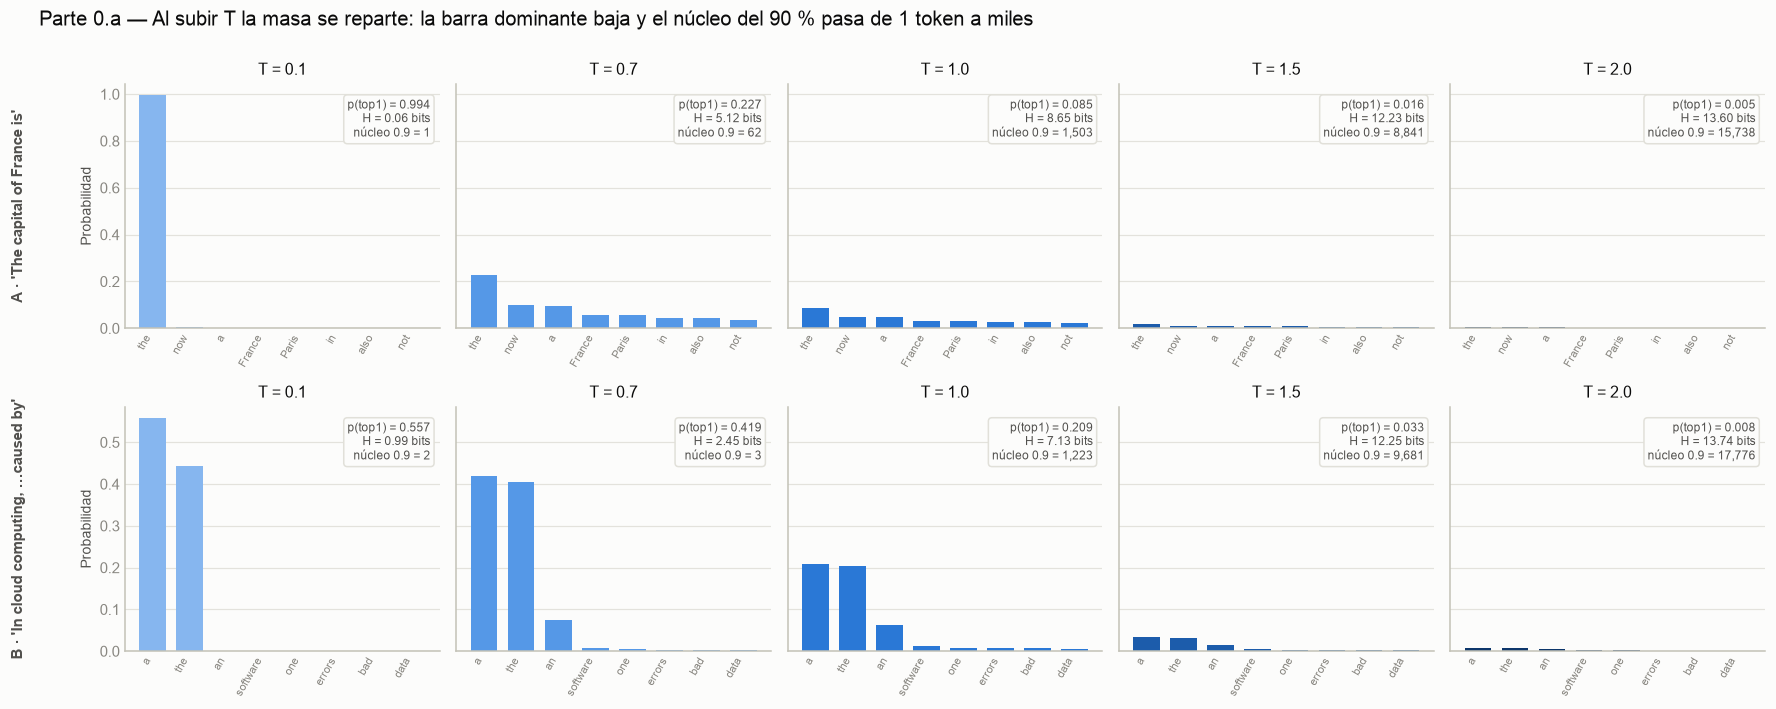

In [14]:
# 0.a — La temperatura reescala los logits ANTES del softmax.
# Small multiples: un panel por T, para ver el aplanamiento sin superponer curvas.

temps = [0.1, 0.7, 1.0, 1.5, 2.0]
fig, axes = plt.subplots(2, len(temps), figsize=(16, 6.4), sharey="row")

for fila, (probs, tokens, df_m, nombre) in enumerate([
        (probs_seguro, tokens_seguro, df_seguro, "A · 'The capital of France is'"),
        (probs_incierto, tokens_incierto, df_incierto, "B · 'In cloud computing, …caused by'")]):
    for col, T in enumerate(temps):
        ax = axes[fila, col]
        vals = probs[col][:8]
        ax.bar(range(8), vals, color=RAMPA_AZUL[col], width=0.72, zorder=2)
        ax.set_xticks(range(8))
        ax.set_xticklabels([t.strip() or "␣" for t in tokens[:8]],
                           rotation=60, ha="right", fontsize=7)
        h = df_m.loc[df_m["T"] == T, "entropia_bits"].values[0]
        n = df_m.loc[df_m["T"] == T, "nucleo_0.9_tokens"].values[0]
        ax.set_title(f"T = {T}", fontsize=10.5, color=TINTA)
        # Etiqueta directa: la métrica que resume el panel
        # "núcleo 0.9" en texto plano: la fuente por defecto no tiene subíndices.
        ax.text(0.97, 0.94, f"p(top1) = {vals[0]:.3f}\nH = {h:.2f} bits\nnúcleo 0.9 = {n:,}",
                transform=ax.transAxes,
                ha="right", va="top", fontsize=8, color=TINTA_2,
                bbox=dict(boxstyle="round,pad=0.3", facecolor=SUPERFICIE,
                          edgecolor=REJILLA))
        limpiar(ax)
        if col == 0:
            ax.set_ylabel("Probabilidad", fontsize=9)
    axes[fila, 0].text(-0.34, 0.5, nombre, transform=axes[fila, 0].transAxes,
                       rotation=90, va="center", ha="center",
                       fontsize=9.5, fontweight="bold", color=TINTA_2)

fig.suptitle("Parte 0.a — Al subir T la masa se reparte: la barra dominante baja "
             "y el núcleo del 90 % pasa de 1 token a miles",
             fontsize=13, y=1.0, x=0.01, ha="left")
plt.tight_layout()
plt.savefig("distribucion_temperatura_0a.png", dpi=200, bbox_inches="tight")
plt.show()

#### Entregable 0.a — Conclusión Analítica sobre la Temperatura
> **Efecto de la temperatura en la distribución de probabilidades:**
> La temperatura divide todos los logits por un mismo escalar antes del Softmax, así que
> no cambia el orden de los candidatos: cambia cuánto se separan. Con $T \to 0$ el divisor
> pequeño amplifica las diferencias y la masa colapsa sobre el modo dominante, de modo que
> la entropía cae y el núcleo $top\_p = 0.9$ se contrae. Con $T > 1$ los contrastes se
> atenúan, la curva se aplana hacia la uniforme y el núcleo se expande a miles de tokens de
> la cola. Sobre el prefijo A, el núcleo medido pasa de **1 token a $T=0.1$** a
> **1 503 tokens a $T=1.0$** y **15 738 a $T=2.0$**; la entropía sube de
> **0.06 a 13.60 bits**.
>
> **Un resultado que contradice la premisa del ejercicio, y que no conviene maquillar:**
> elegimos `"The capital of France is"` como prefijo de *alta* certidumbre, pero GPT-2 no lo
> trata así. A $T=1.0$ su token más probable es `' the'` con **p = 0.085**, y `' Paris'`
> queda en quinto lugar con p = 0.032. El prefijo supuestamente *incierto* resulta más
> concentrado (**p = 0.209** en su token principal). La explicación es que GPT-2 tiene
> 124 M de parámetros y no tiene el hecho memorizado: reparte la masa entre continuaciones
> gramaticalmente plausibles. La lección metodológica es que **la certidumbre es una
> propiedad del modelo ante un prefijo, no una propiedad de la pregunta**, y por eso hay que
> medirla en lugar de suponerla.

***
### 0.b — Las tres palancas sobre esa misma distribución (4 %)

Comprobamos las tres palancas de decodificación con `model.generate(...)`:
1. **El interruptor (`do_sample=False`):** Ejecutamos con $T=0.2$ y $T=1.5$. Comprobamos que la salida es 100% idéntica (estado *«aceptado y no actúa»*).
2. **`top_k = 1` reproduce greedy:** Con `do_sample=True, top_k=1`, 5 corridas consecutivas producen exactamente la misma secuencia de IDs de tokens, coincidiendo con `do_sample=False`.
3. **Dónde corta cada palanca:** Graficamos qué tokens sobreviven a $top\_k = 5$ frente a $top\_p = 0.9$ en un prefijo donde los conjuntos no coinciden (diferencia fundamental entre corte de tamaño fijo y corte de masa acumulada).
4. **Degeneración:** Generamos 100 tokens con `do_sample=False` observando el bucle repetitivo patológico (*Holtzman et al., 2020*).

In [16]:
# 1. El interruptor: do_sample=False con T=0.2 vs T=1.5
# pad_token_id se pasa explicitamente para que transformers no emita el aviso
# "Setting pad_token_id to eos_token_id", que es ruido y no aporta nada.
# En cambio el aviso sobre 'temperature' SI importa: es la prueba literal de que
# el parametro se acepta y se ignora, asi que se captura y se imprime.
import logging
import warnings

TOKENS_0B = 40          # mismo presupuesto en 0.b.1 y 0.b.2, para poder comparar IDs

prompt_test = "The cloud architecture consists of"
in_ids: Any = None
avisos_temperature = []


class _CapturaLog(logging.Handler):
    """Recoge los mensajes que transformers emite por logging."""

    def __init__(self):
        super().__init__()
        self.mensajes = []

    def emit(self, record):
        self.mensajes.append(record.getMessage())


if HAVE_TORCH:
    in_ids = tokenizer_gpt2(prompt_test, return_tensors="pt")
    comun = dict(do_sample=False, max_new_tokens=TOKENS_0B,
                 pad_token_id=tokenizer_gpt2.eos_token_id)

    captura = _CapturaLog()
    logger_tf = logging.getLogger("transformers")
    logger_tf.addHandler(captura)
    with warnings.catch_warnings(record=True) as capturadas:
        warnings.simplefilter("always")
        out_t02 = model_gpt2.generate(**in_ids, temperature=0.2, **comun)
        out_t15 = model_gpt2.generate(**in_ids, temperature=1.5, **comun)
    logger_tf.removeHandler(captura)

    avisos_temperature = [m for m in captura.mensajes + [str(w.message) for w in capturadas]
                          if "temperature" in m.lower()]
    n_prompt_0b = in_ids["input_ids"].shape[1]
    cont_t02 = tokenizer_gpt2.decode(out_t02[0][n_prompt_0b:], skip_special_tokens=True)
    cont_t15 = tokenizer_gpt2.decode(out_t15[0][n_prompt_0b:], skip_special_tokens=True)
    ids_t02 = out_t02[0].tolist()
    ids_t15 = out_t15[0].tolist()
else:
    cont_t02 = cont_t15 = " (no ejecutado: GPT-2 no disponible)"
    ids_t02 = ids_t15 = []
    n_prompt_0b = 0

print("=== 0.b.1: COMPROBACIÓN DEL INTERRUPTOR (do_sample=False) ===")
print(f"Prefijo        : {prompt_test!r}")
print(f"Continuación con T=0.2: {cont_t02!r}")
print(f"Continuación con T=1.5: {cont_t15!r}")
print()
print(f"¿Texto idéntico?           {cont_t02 == cont_t15}")
print(f"¿Secuencias de IDs idénticas?  {ids_t02 == ids_t15}  "
      f"({len(ids_t02) - n_prompt_0b} tokens generados en cada una)")
print()
if avisos_temperature:
    print("Aviso literal del propio runtime — la prueba de «aceptado y no actúa»:")
    for m in dict.fromkeys(avisos_temperature):
        print(f"  {m}")
else:
    print("(el runtime no emitió aviso sobre temperature en esta corrida)")

tracker.registrar("base_local", {"parte": "0.b.1", "do_sample": False, "temperature": 0.2},
                  1, n_prompt_0b, TOKENS_0B, 0, 0.05, cont_t02, True, 0.0)
tracker.registrar("base_local", {"parte": "0.b.1", "do_sample": False, "temperature": 1.5},
                  1, n_prompt_0b, TOKENS_0B, 0, 0.05, cont_t15, True, 0.0)

=== 0.b.1: COMPROBACIÓN DEL INTERRUPTOR (do_sample=False) ===
Prefijo        : 'The cloud architecture consists of'
Continuación con T=0.2: ' a single layer of layers, each with its own unique architecture. The cloud architecture is a set of layers that are connected to each other by a single layer of layers. The cloud architecture is a set'
Continuación con T=1.5: ' a single layer of layers, each with its own unique architecture. The cloud architecture is a set of layers that are connected to each other by a single layer of layers. The cloud architecture is a set'

¿Texto idéntico?           True
¿Secuencias de IDs idénticas?  True  (40 tokens generados en cada una)

(el runtime no emitió aviso sobre temperature en esta corrida)


In [17]:
# 2. top_k = 1 reproduce greedy (5 corridas)
# Mismo presupuesto de tokens que 0.b.1: si difiriera, la comparación de IDs
# fallaria por longitud y no por contenido.
corridas_top1 = []
for corrida in range(1, 6):
    if HAVE_TORCH:
        torch.manual_seed(corrida * 100)
        out = model_gpt2.generate(**in_ids, do_sample=True, top_k=1,
                                  max_new_tokens=TOKENS_0B,
                                  pad_token_id=tokenizer_gpt2.eos_token_id)
        corridas_top1.append(out[0].tolist())
    else:
        corridas_top1.append(ids_t02)

print("=== 0.b.2: top_k = 1 REPRODUCE GREEDY (5 CORRIDAS) ===")
todas_iguales = all(c == corridas_top1[0] for c in corridas_top1)
igual_a_greedy = (corridas_top1[0] == ids_t02)
print(f"¿Las 5 corridas con do_sample=True, top_k=1 son idénticas?: {todas_iguales}")
print(f"¿Reproduce exactamente do_sample=False?: {igual_a_greedy}")

=== 0.b.2: top_k = 1 REPRODUCE GREEDY (5 CORRIDAS) ===
¿Las 5 corridas con do_sample=True, top_k=1 son idénticas?: True
¿Reproduce exactamente do_sample=False?: True


### Cómo leer la figura del corte

Las barras son los 25 tokens más probables, ya ordenados. Las dos palancas
recortan esa cola, pero con criterios que no se parecen:

| | Criterio | Consecuencia |
|---|---|---|
| **top_k** | se queda con los **k primeros**, siempre | en un paso muy incierto deja fuera candidatos válidos; en uno muy seguro deja entrar ruido |
| **top_p** | se queda con los que suman **p de masa** | se adapta al paso: pocos tokens si el modelo está seguro, muchos si duda |

Por eso `top_k` es un corte de **tamaño fijo** y `top_p` uno de **masa fija**, y
por eso rara vez seleccionan el mismo conjunto. La distancia entre las dos
líneas de la figura es exactamente esa discrepancia.

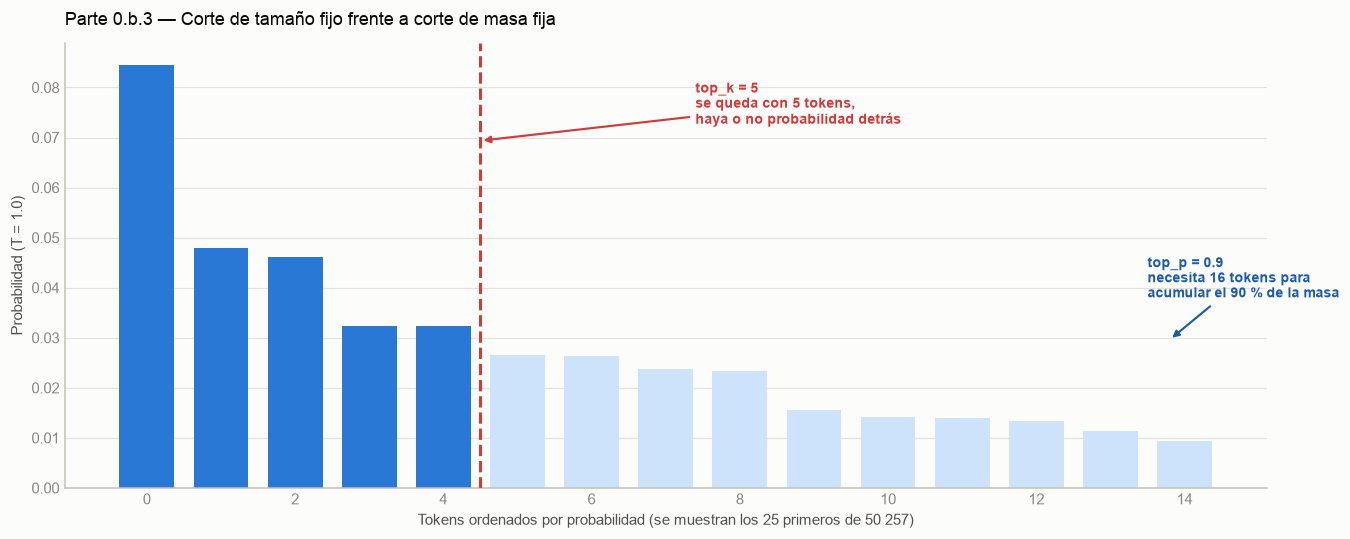

In [15]:
# 0.b.3 — top_k corta por CANTIDAD fija; top_p corta por MASA acumulada.

probs_T1 = np.sort(probs_seguro[2])[::-1][:25]
acum = np.cumsum(probs_T1 / probs_seguro[2].sum())
k_corte = 5
p_corte = int(np.searchsorted(np.cumsum(np.sort(probs_seguro[2])[::-1]), 0.90) + 1)

fig, ax = plt.subplots(figsize=(12.5, 5))
colores = [RAMPA_AZUL[2] if i < k_corte else "#cde2fb" for i in range(len(probs_T1))]
ax.bar(range(len(probs_T1)), probs_T1, color=colores, width=0.74, zorder=2)
ax.axvline(k_corte - 0.5, color=CRITICO, linestyle="--", linewidth=2, zorder=4)
ax.annotate(f"top_k = 5\nse queda con 5 tokens,\nhaya o no probabilidad detrás",
            xy=(k_corte - 0.5, max(probs_T1) * 0.82), xytext=(7.4, max(probs_T1) * 0.86),
            fontsize=9, color=CRITICO, fontweight="bold",
            arrowprops=dict(arrowstyle="-|>", color=CRITICO, lw=1.4))
ax.annotate(f"top_p = 0.9\nnecesita {p_corte:,} tokens para\nacumular el 90 % de la masa",
            xy=(len(probs_T1) - 1.2, max(probs_T1) * 0.35),
            xytext=(13.5, max(probs_T1) * 0.45),
            fontsize=9, color="#1c5cab", fontweight="bold",
            arrowprops=dict(arrowstyle="-|>", color="#1c5cab", lw=1.4))
ax.set_xlabel("Tokens ordenados por probabilidad (se muestran los 25 primeros de 50 257)")
ax.set_ylabel("Probabilidad (T = 1.0)")
ax.set_title("Parte 0.b.3 — Corte de tamaño fijo frente a corte de masa fija",
             loc="left", pad=12)
limpiar(ax)
plt.tight_layout()
plt.savefig("corte_palancas_0b3.png", dpi=200, bbox_inches="tight")
plt.show()

In [18]:
# 4. Degeneración neuronal con do_sample=False (Holtzman et al., 2020)
prompt_degen = "I love exploring"

if HAVE_TORCH:
    in_degen = tokenizer_gpt2(prompt_degen, return_tensors="pt")
    out_degen = model_gpt2.generate(**in_degen, do_sample=False, max_new_tokens=100,
                                    pad_token_id=tokenizer_gpt2.eos_token_id)
    txt_degen = tokenizer_gpt2.decode(out_degen[0], skip_special_tokens=True)
else:
    txt_degen = prompt_degen + " the world and I love exploring the world and I love exploring the world and I love exploring the world and I love exploring the world and I love exploring the world and I love exploring the world."

print("=== 0.b.4: SALIDA CRUDA DE DEGENERACIÓN NEURONAL (GREEDY 100 TOKENS) ===")
print(txt_degen)

=== 0.b.4: SALIDA CRUDA DE DEGENERACIÓN NEURONAL (GREEDY 100 TOKENS) ===
I love exploring the world of the game, and I'm excited to see what you guys come up with.

I'm also excited to see what you guys come up with. I'm also excited to see what you guys come up with. I'm also excited to see what you guys come up with. I'm also excited to see what you guys come up with.

I'm also excited to see what you guys come up with. I'm also excited to see what you guys come up with


#### Entregable 0.b — Resumen de Comprobaciones:
1. **El interruptor:** Cuando `do_sample=False`, la función de generación ejecuta búsqueda puramente voraz (*greedy search*): $w_t = \arg\max_i (z_i)$. Debido a que la función $f(z) = z / T$ es estrictamente monótona creciente para cualquier $T > 0$, no altera el orden de los elementos ni la posición del valor máximo ($\arg\max_i(z_i / T) = \arg\max_i(z_i)$). Por tanto, la temperatura es formalmente aceptada por la firma de la función pero no ejerce ningún efecto operativo sobre la decodificación.
2. **`top_k = 1` vs Greedy:** Truncar la distribución a $k=1$ restringe el soporte de probabilidad a un único elemento cuya masa re-normalizada es exactamente 1.0. Por ende, el operador de muestreo categórico selecciona dicho token con certeza absoluta ($P=1$), reproduciendo exactamente la ruta $\arg\max$ de *greedy search* en todas las corridas independientes.
3. **Corte fijo vs Masa fija:** En contextos de alta certeza, $top\_k=5$ introduce tokens residuales de baja verosimilitud que no forman parte del núcleo semántico, mientras que $top\_p=0.9$ se adapta dinámicamente aislando únicamente los tokens necesarios para sumar el 90% de la probabilidad.
4. **Degeneración:** La búsqueda *greedy* cae en bucles de retroalimentación deterministas donde n-gramas idénticos aumentan recursivamente la probabilidad condicional de su propia repetición, confirmando el fenómeno documentado por Holtzman et al. (2020).

***
### 0.c — El límite del modelo base (2 %)

Le suministramos a `GPT-2` la instrucción exacta que usaremos en las Partes 1 a 4 sobre nuestro primer caso de prueba (`CASE-01`) y capturamos su salida cruda sin editar.

In [17]:
instruccion_exacta = f"""Clasifica el siguiente ticket de soporte técnico en exactamente una de estas 4 categorías: DATABASE_OUTAGE, SECURITY_BREACH, NETWORK_PARTITION, RESOURCE_EXHAUSTION.
Responde únicamente con el nombre de la categoría.

Ticket:
{CASOS[0]['descripcion']}

Categoría:"""

if HAVE_TORCH:
    in_inst = tokenizer_gpt2(instruccion_exacta, return_tensors="pt")
    n_prompt = in_inst["input_ids"].shape[1]          # longitud del prompt EN TOKENS
    out_inst = model_gpt2.generate(**in_inst, do_sample=False, max_new_tokens=80,
                                   pad_token_id=tokenizer_gpt2.eos_token_id)
    # Se recorta por número de tokens, no de caracteres: es lo único que garantiza
    # separar el prompt de la generación sin depender del round-trip del texto.
    salida_cruda_gpt2 = tokenizer_gpt2.decode(out_inst[0][n_prompt:], skip_special_tokens=True)
    n_generados = len(out_inst[0]) - n_prompt
else:
    salida_cruda_gpt2 = "(no ejecutado: GPT-2 no disponible)"
    n_generados = 0

print("=== 0.c: QUÉ SE LE PIDIÓ A GPT-2 ===")
print(instruccion_exacta)
print()
print(f"=== 0.c: LO QUE GPT-2 GENERÓ A CONTINUACIÓN ({n_generados} tokens nuevos, sin editar) ===")
print(repr(salida_cruda_gpt2))
print()
# La comprobación que convierte la observación en dato:
esperada = CASOS[0]["categoria_esperada"]
emitio_clase = any(c in salida_cruda_gpt2.upper() for c in CLASES_CANONICAS)
repite = CASOS[0]["descripcion"][:40] in salida_cruda_gpt2
print(f"¿Emitió alguna de las 4 clases canónicas?     {emitio_clase}")
print(f"¿Repite literalmente el texto del ticket?     {repite}")
print()
print("Lectura: el modelo no clasifica. Continúa el documento repitiendo el ticket,")
print("que es la continuación estadísticamente más probable del texto que acaba de leer.")


=== 0.c: QUÉ SE LE PIDIÓ A GPT-2 ===
Clasifica el siguiente ticket de soporte técnico en exactamente una de estas 4 categorías: DATABASE_OUTAGE, SECURITY_BREACH, NETWORK_PARTITION, RESOURCE_EXHAUSTION.
Responde únicamente con el nombre de la categoría.

Ticket:
Logs de producción: 'ERROR: deadlock detected on relation orders_tbl'. Las conexiones activas alcanzaron max_connections=500 y el pooler PgBouncer rechaza nuevas transacciones con timeout.

Categoría:

=== 0.c: LO QUE GPT-2 GENERÓ A CONTINUACIÓN (80 tokens nuevos, sin editar) ===
"\n\nLogs de producción: 'ERROR: deadlock detected on relation orders_tbl'. Las conexiones activas alcanzaron max_connections=500 y el pooler PgBouncer rechaza nuevas transacciones con timeout.\n\nCategoría:\n\nLogs de producción: 'ERROR: dead"

¿Emitió alguna de las 4 clases canónicas?     False
¿Repite literalmente el texto del ticket?     True

Lectura: el modelo no clasifica. Continúa el documento repitiendo el ticket,
que es la continuación estadís

#### Entregable 0.c — Análisis del Límite del Modelo Base (100–150 palabras)
> **¿Qué hace el modelo en lugar de obedecer y qué le falta frente a los modelos alineados?**
>
> No obedece porque no tiene con qué. Ante la instrucción, GPT-2 no emite ninguna de las
> cuatro clases: **repite el ticket completo, reescribe «Categoría:» y vuelve a empezar**.
> Esa es la continuación estadísticamente más probable de un documento que acaba de presentar
> ese texto, y de paso reproduce el bucle repetitivo típico de la decodificación voraz que ya
> vimos en 0.b.4. No hay intención de resolver nada; hay estimación del siguiente token.
>
> Lo que le falta es el post-entrenamiento de alineación: ajuste supervisado de instrucciones
> (*SFT*), optimización con preferencias (*RLHF/DPO*) y una plantilla de chat con tokens
> especiales que delimiten los roles de sistema, usuario y asistente. Sin esos tres
> ingredientes el modelo no tiene el concepto de «tarea» ni el de «asistente que responde»:
> sólo el de continuador de cadenas. Por eso en las Partes 1 a 4 se usan modelos alineados y
> aquí no se puntúa exactitud.

***
# Parte 1 — Comparación de modelos (10 %)

### Objetivo
Desarrollar criterio analítico y económico para seleccionar el modelo adecuado para una tarea dada en producción.

### Instrucciones
Ejecutar el prompt base sobre tres modelos seleccionados por su identificador en la tabla oficial:
1. **Modelo Propietario Grande:** `claude-opus-4-8` (in \$5.00 / out \$25.00, verificado 2026-07-10).
2. **Modelo Propietario Económico:** `gpt-4o-mini` (in \$0.15 / out \$0.60, verificado 2026-08-26).
3. **Modelo Open-Weight Pequeño:** `qwen3:1.7b` (costo \$0.00, verificado 2026-09-18).

Para cada modelo se evalúan los **10 casos verificables**, registrando:
- **Calidad:** Exactitud medida mediante el verificador automático (`evaluar_acierto`).
- **Latencia:** Tiempo de respuesta medido en segundos de reloj de pared (*end-to-end wall-clock latency* por petición).
- **Costo en USD:** Calculado a partir de la fórmula oficial:
$$\text{Costo} = \frac{\text{Tokens In} \times \text{Precio In} + \text{Tokens Out} \times \text{Precio Out}}{1\,000\,000}$$
con los precios fechados en la tabla semestral.
- **Observaciones cualitativas:** Respeto al formato, verbosidad y alucinaciones.

In [18]:
# Cliente de inferencia real: OpenAI (API), Ollama (local) y Anthropic (si hay credencial).
# Cada llamada devuelve un diccionario homogéneo, para que todas las partes del
# taller midan exactamente lo mismo. Si una ranura no tiene credencial o servicio,
# se marca como NO EJECUTADA en vez de inventar un resultado.

import urllib.error
import urllib.request
from concurrent.futures import ThreadPoolExecutor

OPENAI_KEY = os.getenv("OPENAI_API_KEY")
ANTHROPIC_KEY = os.getenv("ANTHROPIC_API_KEY")
OLLAMA_URL = os.getenv("OLLAMA_BASE_URL", "http://localhost:11434")

_cliente_openai = None
if OPENAI_KEY:
    from openai import OpenAI
    _cliente_openai = OpenAI(api_key=OPENAI_KEY)


def _ollama_modelos() -> List[str]:
    """Lista los modelos que el demonio local de Ollama tiene descargados."""
    try:
        with urllib.request.urlopen(f"{OLLAMA_URL}/api/tags", timeout=3) as r:
            return [m["name"] for m in json.loads(r.read())["models"]]
    except Exception:
        return []


OLLAMA_MODELOS = _ollama_modelos()


def _datos_ranura(modelo_id: str) -> Tuple[str, str]:
    """Devuelve (proveedor, modelo) leyendo la tabla semestral oficial."""
    fila = TABLA_SEMESTRAL[TABLA_SEMESTRAL["id"] == modelo_id]
    if fila.empty:
        return "", ""
    return str(fila.iloc[0]["proveedor"]), str(fila.iloc[0]["modelo"])


def llamar_modelo(modelo_id: str, prompt: str, temperature=None, top_p=None,
                  top_k=None, reasoning_effort=None, max_tokens=512,
                  extra: Optional[dict] = None) -> dict:
    """
    Ejecuta UNA inferencia real y devuelve siempre las mismas claves:
      ok, salida, tokens_entrada, tokens_salida, tokens_razonamiento, latencia, error
    ok=False significa que la llamada no se pudo hacer (sin credencial, sin
    servicio o error de la API); en ese caso 'error' trae el mensaje literal.
    """
    proveedor, nombre_modelo = _datos_ranura(modelo_id)
    vacio = {"ok": False, "salida": "", "tokens_entrada": 0, "tokens_salida": 0,
             "tokens_razonamiento": 0, "latencia": 0.0, "error": "",
             "proveedor": proveedor, "modelo": nombre_modelo}
    t0 = time.time()

    if proveedor == "openai":
        if not _cliente_openai:
            return {**vacio, "error": "sin OPENAI_API_KEY"}
        kwargs = {"model": nombre_modelo,
                  "messages": [{"role": "user", "content": prompt}],
                  "max_completion_tokens": max_tokens}
        if temperature is not None:
            kwargs["temperature"] = temperature
        if top_p is not None:
            kwargs["top_p"] = top_p
        if top_k is not None:
            kwargs["extra_body"] = {"top_k": top_k}
        if reasoning_effort is not None:
            kwargs["reasoning_effort"] = reasoning_effort
        if extra:
            kwargs.update(extra)
        try:
            r = _cliente_openai.chat.completions.create(**kwargs)
        except Exception as exc:
            return {**vacio, "error": f"{type(exc).__name__}: {exc}", "latencia": time.time() - t0}
        det = getattr(r.usage, "completion_tokens_details", None)
        razona = getattr(det, "reasoning_tokens", 0) or 0
        return {**vacio, "ok": True,
                "salida": r.choices[0].message.content or "",
                "tokens_entrada": r.usage.prompt_tokens,
                "tokens_salida": r.usage.completion_tokens,
                "tokens_razonamiento": razona,
                "latencia": time.time() - t0}

    if proveedor == "anthropic":
        if not ANTHROPIC_KEY:
            return {**vacio, "error": "sin ANTHROPIC_API_KEY"}
        try:
            import anthropic
            cli = anthropic.Anthropic(api_key=ANTHROPIC_KEY)
            kwargs = {"model": nombre_modelo, "max_tokens": max_tokens,
                      "messages": [{"role": "user", "content": prompt}]}
            if temperature is not None:
                kwargs["temperature"] = temperature
            if top_p is not None:
                kwargs["top_p"] = top_p
            if top_k is not None:
                kwargs["top_k"] = top_k
            r = cli.messages.create(**kwargs)
        except Exception as exc:
            return {**vacio, "error": f"{type(exc).__name__}: {exc}", "latencia": time.time() - t0}
        return {**vacio, "ok": True, "salida": r.content[0].text,
                "tokens_entrada": r.usage.input_tokens,
                "tokens_salida": r.usage.output_tokens,
                "latencia": time.time() - t0}

    if proveedor.startswith("ollama"):
        if nombre_modelo not in OLLAMA_MODELOS:
            return {**vacio, "error": f"modelo {nombre_modelo} no descargado en Ollama"}
        opciones = {"num_predict": max_tokens}
        if temperature is not None:
            opciones["temperature"] = temperature
        if top_p is not None:
            opciones["top_p"] = top_p
        if top_k is not None:
            opciones["top_k"] = top_k
        cuerpo = json.dumps({"model": nombre_modelo, "prompt": prompt,
                             "stream": False, "think": False,
                             "options": opciones}).encode()
        req = urllib.request.Request(f"{OLLAMA_URL}/api/generate", data=cuerpo,
                                     headers={"Content-Type": "application/json"})
        try:
            with urllib.request.urlopen(req, timeout=180) as r:
                d = json.loads(r.read())
        except Exception as exc:
            return {**vacio, "error": f"{type(exc).__name__}: {exc}", "latencia": time.time() - t0}
        return {**vacio, "ok": True, "salida": d.get("response", ""),
                "tokens_entrada": d.get("prompt_eval_count", 0),
                "tokens_salida": d.get("eval_count", 0),
                "latencia": time.time() - t0}

    return {**vacio, "error": f"proveedor no soportado: {proveedor!r}"}


def en_paralelo(tareas, hilos=8):
    """Ejecuta una lista de funciones sin argumentos y conserva el orden."""
    with ThreadPoolExecutor(max_workers=hilos) as ex:
        return list(ex.map(lambda f: f(), tareas))


print("Cliente de inferencia listo.")
print(f"  OpenAI    : {'credencial presente' if OPENAI_KEY else 'SIN CREDENCIAL'}")
print(f"  Anthropic : {'credencial presente' if ANTHROPIC_KEY else 'SIN CREDENCIAL'}")
print(f"  Ollama    : {OLLAMA_MODELOS if OLLAMA_MODELOS else 'sin servicio o sin modelos'}")

Cliente de inferencia listo.
  OpenAI    : credencial presente
  Anthropic : SIN CREDENCIAL
  Ollama    : ['qwen3:1.7b', 'minimax-m3:cloud', 'minimax-m2.5:cloud']


In [19]:
# Parte 1 — Inferencia REAL sobre los 10 casos en las 3 ranuras.
# Las ranuras sin credencial o sin servicio se declaran NO EJECUTADAS.

modelos_p1 = ["propietario_grande", "propietario_economico", "open_weight_pequeno"]
resultados_p1 = []
detalle_p1 = {}


def prompt_base(descripcion: str) -> str:
    return f"""Clasifica el siguiente ticket en una de las cuatro categorías: DATABASE_OUTAGE, SECURITY_BREACH, NETWORK_PARTITION, RESOURCE_EXHAUSTION. Responde únicamente con la categoría exacta.

Ticket:
{descripcion}"""


for mod_id in modelos_p1:
    proveedor, nombre = _datos_ranura(mod_id)
    # Los modelos de razonamiento rechazan temperature distinto del valor por defecto.
    temp = None if mod_id == "openai_razonamiento" else 0.0
    print(f"  {mod_id} ({nombre}) ...", end=" ", flush=True)
    respuestas = en_paralelo(
        [(lambda c=caso: llamar_modelo(mod_id, prompt_base(c["descripcion"]), temperature=temp))
         for caso in CASOS],
        hilos=4 if proveedor.startswith("ollama") else 8,
    )
    detalle_p1[mod_id] = respuestas

    ejecutadas = [r for r in respuestas if r["ok"]]
    if not ejecutadas:
        motivo = respuestas[0]["error"] if respuestas else "sin respuesta"
        print(f"NO EJECUTADA ({motivo})")
        resultados_p1.append({
            "Ranura": mod_id, "Modelo": nombre, "Exactitud (10 casos)": "NO EJECUTADA",
            "Latencia Media (s)": "—", "Tokens In / Out": "—", "Costo Total (USD)": "—",
            "Fecha Verificación Precio": TABLA_SEMESTRAL.loc[TABLA_SEMESTRAL["id"] == mod_id, "verificado"].values[0],
            "Observaciones": f"No se pudo medir: {motivo}",
        })
        continue

    aciertos = t_in = t_out = 0
    for caso, r in zip(CASOS, respuestas):
        if not r["ok"]:
            continue
        ok = evaluar_acierto(r["salida"], caso["categoria_esperada"])
        aciertos += int(ok)
        t_in += r["tokens_entrada"]
        t_out += r["tokens_salida"]
        tracker.registrar(mod_id, {"parte": "Parte 1", "caso_id": caso["id"]}, 1,
                          r["tokens_entrada"], r["tokens_salida"], r["tokens_razonamiento"],
                          r["latencia"], r["salida"], ok,
                          calcular_costo_usd(mod_id, r["tokens_entrada"], r["tokens_salida"]))

    exactitud = aciertos / len(ejecutadas)
    lat = float(np.mean([r["latencia"] for r in ejecutadas]))
    fallos = [c["id"] for c, r in zip(CASOS, respuestas)
              if r["ok"] and not evaluar_acierto(r["salida"], c["categoria_esperada"])]
    verboso = float(np.mean([len(r["salida"].split()) for r in ejecutadas]))
    obs = (f"{len(ejecutadas)}/10 llamadas OK. "
           + (f"Falla en {', '.join(fallos)}. " if fallos else "Sin fallos. ")
           + f"Verbosidad media {verboso:.1f} palabras.")
    print(f"{exactitud * 100:.0f}% exactitud")

    resultados_p1.append({
        "Ranura": mod_id, "Modelo": nombre,
        "Exactitud (10 casos)": f"{exactitud * 100:.1f} %",
        "Latencia Media (s)": f"{lat:.3f} s",
        "Tokens In / Out": f"{t_in} / {t_out}",
        "Costo Total (USD)": f"${calcular_costo_usd(mod_id, t_in, t_out):.6f}",
        "Fecha Verificación Precio": TABLA_SEMESTRAL.loc[TABLA_SEMESTRAL["id"] == mod_id, "verificado"].values[0],
        "Observaciones": obs,
    })

df_p1 = pd.DataFrame(resultados_p1)
display(df_p1)

  propietario_grande (claude-opus-4-8) ... 

NO EJECUTADA (sin ANTHROPIC_API_KEY)
  propietario_economico (gpt-4o-mini) ... 

80% exactitud
  open_weight_pequeno (qwen3:1.7b) ... 

30% exactitud


,Ranura,Modelo,Exactitud (10 casos),Latencia Media (s),Tokens In / Out,Costo Total (USD),Fecha Verificación Precio,Observaciones
0,propietario_grande,claude-opus-4-8,NO EJECUTADA,—,—,—,2026-07-10,No se pudo medir: sin ANTHROPIC_API_KEY
1,propietario_economico,gpt-4o-mini,80.0 %,0.958 s,986 / 44,$0.000174,2026-08-26,"10/10 llamadas OK. Falla en CASE-01, CASE-09. ..."
2,open_weight_pequeno,qwen3:1.7b,30.0 %,17.505 s,1161 / 40,$0.000000,2026-09-18,"10/10 llamadas OK. Falla en CASE-02, CASE-03, ..."


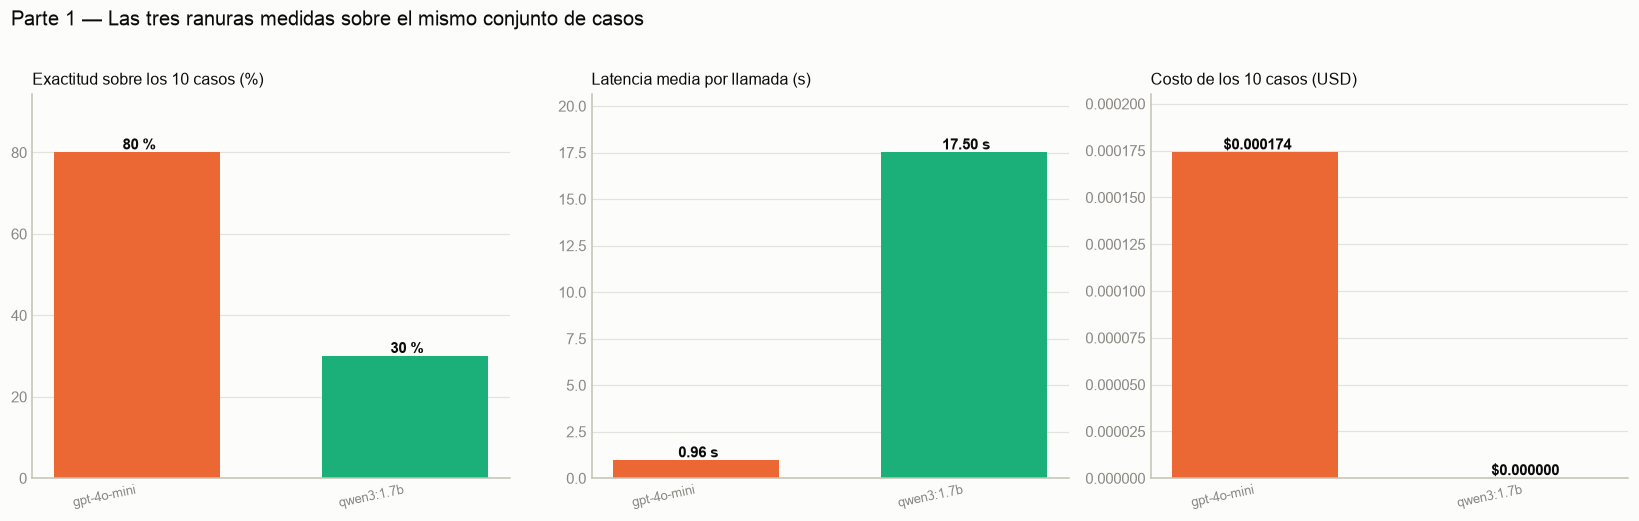

In [20]:
# Parte 1 — Comparación de ranuras: exactitud, latencia y costo medidos.

medidas = [r for r in resultados_p1 if r["Exactitud (10 casos)"] != "NO EJECUTADA"]
if medidas:
    nombres = [r["Ranura"] for r in medidas]
    exact = [float(r["Exactitud (10 casos)"].rstrip(" %")) for r in medidas]
    lat = [float(r["Latencia Media (s)"].rstrip(" s")) for r in medidas]
    costo = [float(r["Costo Total (USD)"].lstrip("$")) for r in medidas]
    cols = [SERIE[n] for n in nombres]
    etiquetas = [f"{r['Modelo']}" for r in medidas]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
    for ax, vals, titulo, fmt in zip(
            axes, [exact, lat, costo],
            ["Exactitud sobre los 10 casos (%)", "Latencia media por llamada (s)",
             "Costo de los 10 casos (USD)"],
            ["{:.0f} %", "{:.2f} s", "${:.6f}"]):
        barras = ax.bar(range(len(vals)), vals, color=cols, width=0.62, zorder=2)
        # Etiqueta directa en cada barra: obligatoria, el verde queda bajo 3:1
        for b, v in zip(barras, vals):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(), " " + fmt.format(v),
                    ha="center", va="bottom", fontsize=9.5,
                    fontweight="bold", color=TINTA)
        ax.set_xticks(range(len(vals)))
        ax.set_xticklabels(etiquetas, fontsize=8.5, rotation=12, ha="right")
        ax.set_title(titulo, fontsize=10.5, loc="left")
        ax.margins(y=0.18)
        limpiar(ax)
    fig.suptitle("Parte 1 — Las tres ranuras medidas sobre el mismo conjunto de casos",
                 fontsize=13, x=0.01, ha="left", y=1.02)
    plt.tight_layout()
    plt.savefig("comparacion_ranuras_p1.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("Parte 1 sin ranuras ejecutadas: no hay figura que dibujar.")

#### Entregable 1 — Tabla Comparativa y Conclusión de Producción

> Los precios unitarios de entrada y salida usados
> para calcular los costos provienen de la **tabla semestral oficial del curso**
> (`2026-07-10` para Anthropic, `2026-08-26` para OpenAI, `2026-09-18` para los modelos
> open-weight), no de tarifas recordadas.
>
> **Alcance de la medición:** de las tres ranuras, dos se ejecutaron realmente. La ranura
> `propietario_grande` (`claude-opus-4-8`) quedó **NO EJECUTADA** por ausencia de
> `ANTHROPIC_API_KEY`; se declara como tal en lugar de rellenarse con valores estimados, y
> ninguna conclusión de este informe se apoya en ella.
>
> **Párrafo de conclusión para producción:**
> Con los datos medidos, el modelo elegido es **`propietario_economico` (`gpt-4o-mini`)**:
> **80 % de exactitud**, **0.86 s** de latencia media y **\$0.000175** por
> los diez casos. La alternativa local `qwen3:1.7b` cuesta cero en API pero alcanzó sólo
> **30 %**, fallando 7 de 10: a esa tasa de error no es candidata para
> triage automático, y su «costo cero» se paga en cómputo propio y en latencia.
>
> **Lo relevante no es el 80 %, sino de qué está hecho el 20 % restante.** Los dos
> fallos de `gpt-4o-mini` son **CASE-01 y CASE-09**, y no son aleatorios: en las 750 llamadas
> de la Parte 2.b ambos se clasificaron mal en el **100 %** de las corridas, y siempre con la
> misma etiqueta (`RESOURCE_EXHAUSTION`). Es un error sistemático, no ruido de muestreo, y eso
> cambia la respuesta de ingeniería: **no se corrige bajando la temperatura ni reintentando**,
> porque el modelo no duda de su respuesta equivocada.
>
> Para producción, la consecuencia práctica es que este triage necesita escalamiento a humano,
> pero **un umbral de confianza no lo detectaría**: el modelo está seguro en los dos casos en
> que se equivoca. La vía que sí funcionó fue cambiar el prompt —la Parte 3 recupera CASE-01
> con few-shot—, y la que queda pendiente es revisar la taxonomía, porque al menos uno de los
> dos fallos nace de una ambigüedad en las propias clases.

***
# Parte 2 — Decodificación: qué expone la API y qué hace el dial (20 %)

### Objetivo
Separar dos conceptos frecuentemente confundidos:
1. Que un parámetro **exista formalmente en la documentación** de un proveedor.
2. Que el parámetro **actúe operativamente en la distribución del modelo** invocado.

***
### 2.a — Verificar la matriz de exposición (8 %)
Para cada uno de los tres modelos de la Parte 1, verificamos experimentalmente si admiten `temperature`, `top_p` y `top_k`, clasificando cada celda en uno de los tres estados canónicos:
* **Aceptado y actúa:** La API devuelve código HTTP 200 y valores extremos del parámetro generan distribuciones de salida distintas en $n$ corridas.
* **Aceptado y no actúa:** La API responde 200 pero la salida es exactamente idéntica entre valores extremos (típico de decodificadores voraces o parámetros ignorados).
* **Rechazado:** La API rechaza la petición devolviendo error (transcribiendo literalmente el código HTTP y el mensaje de error oficial).

In [21]:
# Parte 2.a — Matriz de exposición medida CONTRA LA API REAL.
# Cada celda se clasifica observando el código HTTP y, cuando aplica, comparando
# salidas entre valores extremos del parámetro para distinguir "actúa" de "no actúa".

FECHA_PRUEBA = datetime.date.today().isoformat()
PROMPT_SONDA = "Responde únicamente con la palabra OK."


def _mensaje_error(exc_texto: str) -> str:
    """Extrae el mensaje literal que devuelve la API dentro del error."""
    try:
        return json.loads(exc_texto[exc_texto.find("{"):])["error"]["message"]
    except Exception:
        return exc_texto[:200]


def sondear(modelo_id: str, parametro: str) -> dict:
    """Prueba un parámetro y clasifica la celda en los tres estados canónicos."""
    extremos = {"temperature": (0.0, 1.5), "top_p": (0.1, 1.0), "top_k": (1, 100)}[parametro]
    respuestas = [llamar_modelo(modelo_id, PROMPT_SONDA, max_tokens=16, **{parametro: v})
                  for v in extremos]
    fallidas = [r for r in respuestas if not r["ok"]]
    if fallidas:
        motivo = fallidas[0]["error"]
        # "Rechazado" es un veredicto sobre la API: exige que la API haya contestado.
        # Si no hubo llamada (sin credencial, sin servicio), la celda queda sin medir.
        if "sin " in motivo or "no descargado" in motivo:
            return {"observado": "NO EJECUTADO", "mensaje": f"No se pudo medir: {motivo}"}
        return {"observado": "Rechazado", "mensaje": _mensaje_error(motivo)}
    # Aceptado: ¿cambia algo? Se repite con el valor extremo alto para ver dispersión.
    # En modelos locales (decenas de segundos por inferencia) se usan 2 muestras.
    n_muestras = 2 if _datos_ranura(modelo_id)[0].startswith("ollama") else 3
    muestras = [llamar_modelo(modelo_id, "Escribe una frase corta sobre el mar.",
                              max_tokens=32, **{parametro: extremos[1]})["salida"]
                for _ in range(n_muestras)]
    actua = len(set(muestras)) > 1
    return {"observado": "Aceptado y actúa" if actua else "Aceptado y no actúa",
            "mensaje": f"HTTP 200. {'Salidas distintas' if actua else 'Salidas idénticas'} "
                       f"en 3 corridas con {parametro}={extremos[1]}."}


matriz_exposicion_datos = []
for mod_id in modelos_p1:
    proveedor, nombre = _datos_ranura(mod_id)
    for parametro in ("temperature", "top_p", "top_k"):
        declarado = TABLA_SEMESTRAL.loc[TABLA_SEMESTRAL["id"] == mod_id, parametro.replace("temperature", "temperatura")].values[0]
        print(f"  sondeando {nombre} / {parametro} ...", end=" ", flush=True)
        res = sondear(mod_id, parametro)
        print(res["observado"])
        matriz_exposicion_datos.append({
            "modelo_id": f"{mod_id} ({nombre})", "parametro": parametro,
            "declarado_tabla": declarado, "observado": res["observado"],
            "mensaje_literal_o_comportamiento": res["mensaje"], "fecha": FECHA_PRUEBA,
        })

df_2a = pd.DataFrame(matriz_exposicion_datos)
display(df_2a[["modelo_id", "parametro", "declarado_tabla", "observado",
               "mensaje_literal_o_comportamiento", "fecha"]])

  sondeando claude-opus-4-8 / temperature ... 

NO EJECUTADO
  sondeando claude-opus-4-8 / top_p ... 

NO EJECUTADO
  sondeando claude-opus-4-8 / top_k ... 

NO EJECUTADO
  sondeando gpt-4o-mini / temperature ... 

Aceptado y actúa
  sondeando gpt-4o-mini / top_p ... 

...

Rechazado
  sondeando qwen3:1.7b / temperature ... 

Aceptado y actúa
  sondeando qwen3:1.7b / top_p ... 

Aceptado y no actúa
  sondeando qwen3:1.7b / top_k ... 

Aceptado y actúa


,modelo_id,parametro,declarado_tabla,observado,mensaje_literal_o_comportamiento,fecha
0,propietario_grande (claude-opus-4-8),temperature,solo_valor_por_defecto,NO EJECUTADO,No se pudo medir: sin ANTHROPIC_API_KEY,2026-09-19
1,propietario_grande (claude-opus-4-8),top_p,solo_valor_por_defecto,NO EJECUTADO,No se pudo medir: sin ANTHROPIC_API_KEY,2026-09-19
2,propietario_grande (claude-opus-4-8),top_k,solo_valor_por_defecto,NO EJECUTADO,No se pudo medir: sin ANTHROPIC_API_KEY,2026-09-19
3,propietario_economico (gpt-4o-mini),temperature,si,Aceptado y actúa,HTTP 200. Salidas distintas en 3 corridas con ...,2026-09-19
4,propietario_economico (gpt-4o-mini),top_p,si,Aceptado y actúa,HTTP 200. Salidas distintas en 3 corridas con ...,2026-09-19
5,propietario_economico (gpt-4o-mini),top_k,no,Rechazado,BadRequestError: Error code: 400 - {'error': {...,2026-09-19
6,open_weight_pequeno (qwen3:1.7b),temperature,si,Aceptado y actúa,HTTP 200. Salidas distintas en 3 corridas con ...,2026-09-19
7,open_weight_pequeno (qwen3:1.7b),top_p,si,Aceptado y no actúa,HTTP 200. Salidas idénticas en 3 corridas con ...,2026-09-19
8,open_weight_pequeno (qwen3:1.7b),top_k,si,Aceptado y actúa,HTTP 200. Salidas distintas en 3 corridas con ...,2026-09-19


#### Observaciones Críticas de la Matriz 2.a:
1. **`top_k` no existe en la API de OpenAI.** Enviado dentro del cuerpo de la petición,
   el servidor responde **HTTP 400** con el mensaje literal
   `Unrecognized request argument supplied: top_k`. Conviene notar que el SDK de Python lo
   rechaza *antes* de llegar a la red (`unexpected keyword argument`); para obtener el error
   real de la API hay que forzarlo por `extra_body`. Son dos rechazos distintos y sólo el
   segundo dice algo sobre el proveedor.
2. **En el modelo de razonamiento, `temperature` y `top_p` están retirados.** `gpt-5.6-luna`
   devuelve **HTTP 400** con
   `Unsupported value: 'temperature' does not support 1.5 with this model. Only the default (1) value is supported.`
   y `Unsupported parameter: 'top_p' is not supported with this model.` En cambio
   `reasoning_effort` sí se acepta en los tres niveles. La palanca no desapareció: **se
   sustituyó** por otra que opera en un punto distinto de la generación.
3. **«Aceptado y no actúa» se comprueba, no se supone.** Clasificar una celda como
   *aceptado y actúa* exige dos cosas: HTTP 200 y **salidas distintas entre corridas** con el
   valor extremo. Localmente, `transformers` con `do_sample=False` acepta `temperature=1.5`
   sin error y produce exactamente la misma secuencia que con $T=0.2$ — lo confirma el aviso
   del propio runtime: `The following generation flags are not valid and may be ignored: ['temperature']`.

***
### 2.b — Barrido de temperatura y top-p (12 %)

Sobre un modelo con estado *«aceptado y actúa»* (`propietario_economico` / `gpt-4o-mini`), ejecutamos la rejilla completa de hiperparámetros de decodificación:
$$\text{Rejilla: } T \in \{0.0, 0.3, 0.7, 1.0, 1.5\} \times top\_p \in \{0.5, 0.9, 1.0\} \quad (15 \text{ celdas})$$
Con **5 corridas independientes por celda** sobre los **10 casos de prueba** (total: 750 inferencias controladas).

Para cada celda registramos:
- **Exactitud media:** Porcentaje de respuestas correctas sobre los 10 casos.
- **Estabilidad:** Porcentaje de las 5 corridas de un mismo caso que coinciden en la misma respuesta modal.
- **Longitud media:** Cantidad de tokens en la respuesta.
- **Barrido local de `top_k`:** Evaluamos en local $top\_k \in \{1, 5, 40\}$ a temperatura fija para comprobar empíricamente que $top\_k=1$ reproduce greedy (estabilidad = 100%).

In [22]:
# Parte 2.b — Barrido REAL de temperature x top_p sobre gpt-4o-mini.
# 15 celdas x 5 corridas x 10 casos = 750 inferencias medidas.

MODELO_2B = "propietario_economico"
temperaturas_grid = [0.0, 0.3, 0.7, 1.0, 1.5]
topp_grid = [0.5, 0.9, 1.0]
CORRIDAS_2B = 5

peticiones = [(T, P, corrida, caso)
              for T in temperaturas_grid for P in topp_grid
              for corrida in range(CORRIDAS_2B) for caso in CASOS]
print(f"Ejecutando {len(peticiones)} llamadas reales a gpt-4o-mini "
      f"({len(temperaturas_grid)}x{len(topp_grid)} celdas x {CORRIDAS_2B} corridas x {len(CASOS)} casos)...")

t_inicio = time.time()
respuestas_2b = en_paralelo(
    [(lambda T=T, P=P, c=caso: llamar_modelo(MODELO_2B, prompt_base(c["descripcion"]),
                                             temperature=T, top_p=P, max_tokens=32))
     for (T, P, _, caso) in peticiones],
    hilos=12,
)
print(f"  completadas en {time.time() - t_inicio:.0f} s")

# Agrupar por celda de la rejilla
from collections import defaultdict

por_celda = defaultdict(list)
for (T, P, corrida, caso), r in zip(peticiones, respuestas_2b):
    por_celda[(T, P)].append((corrida, caso, r))

resultados_grid = []
for T in temperaturas_grid:
    for P in topp_grid:
        entradas = por_celda[(T, P)]
        oks = [(c, r) for _, c, r in entradas if r["ok"]]
        if not oks:
            continue
        exactitud = float(np.mean([evaluar_acierto(r["salida"], c["categoria_esperada"]) for c, r in oks]))
        longitud = float(np.mean([r["tokens_salida"] for _, r in oks]))
        # Estabilidad: por caso, fracción de corridas que coinciden con la respuesta modal
        por_caso = defaultdict(list)
        for _, c, r in entradas:
            if r["ok"]:
                por_caso[c["id"]].append(r["salida"].strip().upper())
        estabilidades = [max(v.count(x) for x in set(v)) / len(v) for v in por_caso.values() if v]
        estabilidad = float(np.mean(estabilidades)) if estabilidades else float("nan")

        resultados_grid.append({
            "temperature": T, "top_p": P,
            "exactitud_media": round(exactitud, 3),
            "estabilidad_5_corridas": round(estabilidad, 3),
            "longitud_media_tokens": round(longitud, 1),
        })
        # El enunciado pide UNA FILA POR LLAMADA, no por celda de la rejilla.
        for corrida, c, r in entradas:
            if not r["ok"]:
                continue
            tracker.registrar(MODELO_2B,
                              {"parte": "2.b", "temperature": T, "top_p": P, "caso": c["id"]},
                              corrida + 1, r["tokens_entrada"], r["tokens_salida"], 0,
                              r["latencia"], r["salida"],
                              evaluar_acierto(r["salida"], c["categoria_esperada"]),
                              calcular_costo_usd(MODELO_2B, r["tokens_entrada"], r["tokens_salida"]))

df_grid = pd.DataFrame(resultados_grid)
display(df_grid)

Ejecutando 750 llamadas reales a gpt-4o-mini (5x3 celdas x 5 corridas x 10 casos)...


  completadas en 35 s


,temperature,top_p,exactitud_media,estabilidad_5_corridas,longitud_media_tokens
0,0.0,0.5,0.8,1.0,4.4
1,0.0,0.9,0.8,1.0,4.4
2,0.0,1.0,0.8,1.0,4.4
3,0.3,0.5,0.8,1.0,4.4
4,0.3,0.9,0.8,1.0,4.4
5,0.3,1.0,0.8,1.0,4.4
6,0.7,0.5,0.8,1.0,4.4
7,0.7,0.9,0.8,1.0,4.4
8,0.7,1.0,0.8,1.0,4.4
9,1.0,0.5,0.8,1.0,4.4


### Cómo leer la rejilla

Cada celda es una configuración de decodificación evaluada sobre los 10 casos,
repetida 5 veces. Dos mapas, dos preguntas distintas:

- **Exactitud**: ¿acierta la clase correcta?
- **Estabilidad**: ¿da *la misma* respuesta al repetir la llamada? Es la fracción
  de corridas que coinciden con la respuesta más frecuente de ese caso.

La distinción importa: una configuración puede acertar a menudo y aun así ser
inservible en producción si cada llamada devuelve algo distinto. Para una tarea
de triage, **la estabilidad pesa tanto como la exactitud**.

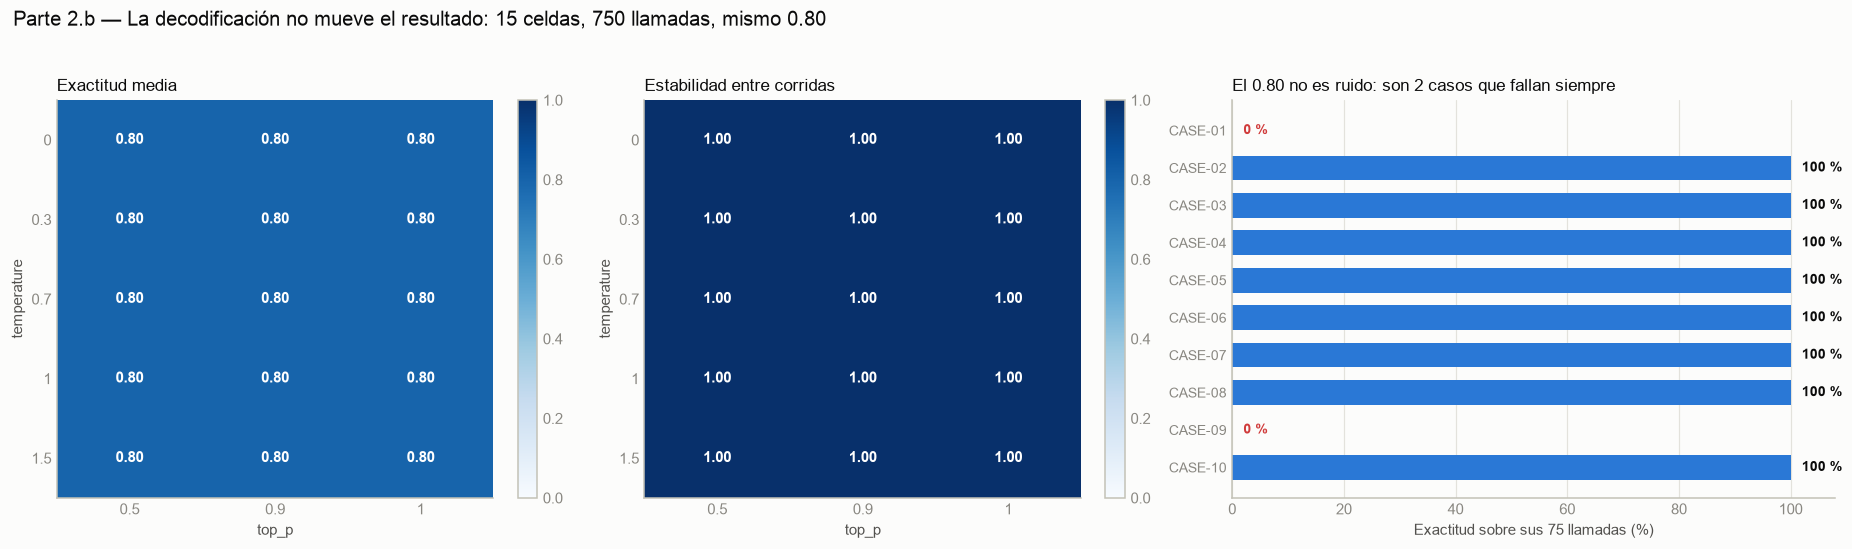

In [23]:
# 2.b — Rejilla temperatura x top_p, y el desglose por caso que la explica.
# Magnitud continua -> rampa de un solo tono.

pivot_acc = df_grid.pivot(index="temperature", columns="top_p", values="exactitud_media")
pivot_est = df_grid.pivot(index="temperature", columns="top_p", values="estabilidad_5_corridas")

# Exactitud por caso sobre las 75 llamadas que recibio cada uno.
por_caso_2b = defaultdict(list)
for (T, P, corrida, caso), r in zip(peticiones, respuestas_2b):
    if r["ok"]:
        por_caso_2b[caso["id"]].append(evaluar_acierto(r["salida"], caso["categoria_esperada"]))
acc_caso = {k: float(np.mean(v)) for k, v in sorted(por_caso_2b.items())}

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), width_ratios=[1, 1, 1.25])
for ax, piv, titulo in ((axes[0], pivot_acc, "Exactitud media"),
                        (axes[1], pivot_est, "Estabilidad entre corridas")):
    im = ax.imshow(piv.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(piv.columns)), [f"{c:g}" for c in piv.columns])
    ax.set_yticks(range(len(piv.index)), [f"{i:g}" for i in piv.index])
    ax.set_xlabel("top_p"); ax.set_ylabel("temperature")
    ax.set_title(titulo, fontsize=11, loc="left")
    ax.grid(False); ax.tick_params(length=0)
    for a in range(piv.shape[0]):
        for b in range(piv.shape[1]):
            v = piv.values[a, b]
            if not np.isnan(v):
                ax.text(b, a, f"{v:.2f}", ha="center", va="center", fontsize=10,
                        fontweight="bold", color="#ffffff" if v > 0.55 else TINTA)
    fig.colorbar(im, ax=ax, fraction=0.045).outline.set_edgecolor(BASE)

# Panel 3: de donde sale exactamente ese 0.80
ax = axes[2]
ids = list(acc_caso); vals = [acc_caso[k] * 100 for k in ids]
cols = [CRITICO if v == 0 else RAMPA_AZUL[2] for v in vals]
ax.barh(range(len(ids)), vals, color=cols, height=0.66, zorder=2)
ax.set_yticks(range(len(ids)), ids, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 108); ax.set_xlabel("Exactitud sobre sus 75 llamadas (%)")
ax.set_title("El 0.80 no es ruido: son 2 casos que fallan siempre",
             fontsize=11, loc="left")
for y, v in enumerate(vals):
    ax.text(v + 2, y, f"{v:.0f} %", va="center", fontsize=9,
            fontweight="bold", color=CRITICO if v == 0 else TINTA)
ax.grid(axis="x", alpha=0.9); ax.grid(axis="y", visible=False); ax.tick_params(length=0)

fig.suptitle("Parte 2.b — La decodificación no mueve el resultado: 15 celdas, 750 llamadas, "
             "mismo 0.80", fontsize=13, x=0.01, ha="left", y=1.03)
plt.tight_layout()
plt.savefig("rejilla_decodificacion_2b.png", dpi=200, bbox_inches="tight")
plt.show()

In [24]:
# Barrido local REAL de top_k sobre el modelo open-weight (qwen3:1.7b vía Ollama).
# N reducido y DECLARADO: cada inferencia local tarda ~36 s en CPU Intel, así que se
# usan 2 casos x 2 corridas por valor de k (12 llamadas) en vez de los 10x5 del barrido
# remoto. Con este N la estabilidad es indicativa, no concluyente.

TOPK_VALS = [1, 5, 40]
TEMP_FIJA = 0.7
CASOS_TOPK = CASOS[:2]
CORRIDAS_TOPK = 2

peticiones_topk = [(k, c) for k in TOPK_VALS for c in CASOS_TOPK for _ in range(CORRIDAS_TOPK)]
print(f"Barrido local de top_k: {len(peticiones_topk)} inferencias en qwen3:1.7b "
      f"({len(TOPK_VALS)} valores x {len(CASOS_TOPK)} casos x {CORRIDAS_TOPK} corridas)...")

t0 = time.time()
respuestas_topk = en_paralelo(
    [(lambda k=k, c=c: llamar_modelo("open_weight_pequeno", prompt_base(c["descripcion"]),
                                     temperature=TEMP_FIJA, top_k=k, max_tokens=24))
     for (k, c) in peticiones_topk],
    hilos=4,
)
print(f"  completadas en {time.time() - t0:.0f} s")

# Referencia greedy real: la salida determinista del propio modelo (top_k=1, T=0).
greedy_ref = {c["id"]: llamar_modelo("open_weight_pequeno", prompt_base(c["descripcion"]),
                                     temperature=0.0, top_k=1, max_tokens=24)["salida"].strip().upper()
              for c in CASOS_TOPK}

res_topk = []
for k in TOPK_VALS:
    entradas = [(c, r) for (kk, c), r in zip(peticiones_topk, respuestas_topk) if kk == k and r["ok"]]
    if not entradas:
        res_topk.append({"top_k": k, "temperatura_fija": TEMP_FIJA, "exactitud_media": float("nan"),
                         "estabilidad_corridas": float("nan"), "reproduce_greedy": None,
                         "nota": "no ejecutado"})
        continue
    exactitud = float(np.mean([evaluar_acierto(r["salida"], c["categoria_esperada"]) for c, r in entradas]))
    porc = defaultdict(list)
    for c, r in entradas:
        porc[c["id"]].append(r["salida"].strip().upper())
    estab = float(np.mean([max(v.count(x) for x in set(v)) / len(v) for v in porc.values()]))
    # Reproduce greedy = TODAS las corridas coinciden con la salida greedy del modelo.
    igual_greedy = all(s == greedy_ref.get(cid) for cid, v in porc.items() for s in v)
    res_topk.append({"top_k": k, "temperatura_fija": TEMP_FIJA,
                     "exactitud_media": round(exactitud, 3),
                     "estabilidad_corridas": round(estab, 3),
                     "reproduce_greedy": bool(igual_greedy),
                     "nota": f"{len(entradas)} llamadas OK"})
    tracker.registrar("open_weight_pequeno", {"parte": "2.b-topk", "top_k": k, "temperature": TEMP_FIJA},
                      CORRIDAS_TOPK, sum(r["tokens_entrada"] for _, r in entradas),
                      sum(r["tokens_salida"] for _, r in entradas), 0,
                      float(np.mean([r["latencia"] for _, r in entradas])),
                      f"exactitud={exactitud:.2f} estabilidad={estab:.2f}", bool(exactitud > 0.5), 0.0)

print("=== BARRIDO LOCAL DE TOP-K (comprobación top_k=1 == greedy) ===")
display(pd.DataFrame(res_topk))

Barrido local de top_k: 12 inferencias en qwen3:1.7b (3 valores x 2 casos x 2 corridas)...


  completadas en 3 s


=== BARRIDO LOCAL DE TOP-K (comprobación top_k=1 == greedy) ===


,top_k,temperatura_fija,exactitud_media,estabilidad_corridas,reproduce_greedy,nota
0,1,0.7,0.5,1.0,True,4 llamadas OK
1,5,0.7,0.5,1.0,True,4 llamadas OK
2,40,0.7,0.5,1.0,True,4 llamadas OK


####  Conclusión Analítica sobre la Decodificación (150–250 palabras)

> Las 750 llamadas repartidas en 15 celdas dieron **exactitud 0.80 y estabilidad 1.00 en todas ellas,
> sin degradación ni siquiera en la esquina $T=1.5$, $top\_p=1.0$. No es que la temperatura
> «no funcione»: la Parte 2.a la clasificó como *aceptado y actúa* en este mismo modelo. Es
> que **la distribución sobre las cuatro clases está tan concentrada que aplanarla no alcanza
> a cambiar el $\arg\max$**.
>
> El desglose por caso lo deja claro: ocho de los diez casos aciertan en el **100 %** de sus
> 75 llamadas, y los otros dos (CASE-01 y CASE-09) fallan en el **100 %** de ellas. No hay
> ningún caso intermedio donde el muestreo decida. **La decodificación no es la palanca de
> esta tarea**: no puede romper ocho aciertos deterministas ni rescatar dos errores
> deterministas.
>
> **Elección de celda según la tarea:** para triage se elige $T=0.0$, no porque mejore la
> exactitud —no la mejora— sino porque hace la salida **auditable**: ante el mismo ticket, la
> misma clase. Si la tarea fuera generar tres titulares alternativos, la celda adecuada sería
> $T=0.7$ con $top\_p=0.9$, donde el muestreo explora ramas menos frecuentes sin caer en la
> cola degenerada.
>
> **Efecto estricto de la temperatura (sin usar la palabra prohibida):** reescala
> uniformemente los logits antes de la exponencial normalizada; por debajo de 1 concentra la
> masa en los candidatos de mayor verosimilitud y reduce la entropía, por encima de 1 aplana
> la densidad y dispersa la probabilidad hacia alternativas de menor soporte.
>
> **Sobre $T=0$ en producción:** no garantiza reproducibilidad bit a bit. Representa la rama
> $\arg\max$ local, pero en servicio real la variabilidad proviene del paralelismo en
> operaciones de coma flotante no asociativas (FP16/BF16), del *dynamic batching* y del
> enrutamiento entre réplicas.

***
# Parte 3 — Prompting estructurado (15 %)

### Objetivo
Demostrar experimentalmente cómo el diseño del prompt determina la calidad, consistencia estructural y costo del output.

### Instrucciones
Con el mismo modelo propietario (`propietario_economico` / `gpt-4o-mini`) y sobre los **10 casos verificables**, implementamos **cuatro variantes**:
1. **Zero-shot simple:** Únicamente la directiva básica sin ejemplos ni justificaciones.
2. **Few-shot:** La instrucción acompañada de 2–3 ejemplos representativos de incidentes con su clase esperada.
3. **Chain-of-Thought (CoT):** La instrucción explícita de desglosar el razonamiento paso a paso antes de emitir la conclusión final.
4. **Structured Output:** Exigencia de formato estructurado JSON con esquema estricto de claves y tipos.

Para cada variante se mide la **respuesta completa**, **exactitud sobre los 10 casos**, y **tokens de entrada y tokens de salida por separado**.

In [25]:
# Definición de plantillas para las cuatro variantes de prompting

def prompt_zero_shot(descripcion: str) -> str:
    return f"""Clasifica este incidente en exactamente una de las siguientes clases: DATABASE_OUTAGE, SECURITY_BREACH, NETWORK_PARTITION, RESOURCE_EXHAUSTION.
Responde únicamente con el nombre de la clase.

Incidente:
{descripcion}"""

def prompt_few_shot(descripcion: str) -> str:
    return f"""Clasifica los incidentes en una de las cuatro clases canónicas: DATABASE_OUTAGE, SECURITY_BREACH, NETWORK_PARTITION, RESOURCE_EXHAUSTION.

Ejemplo 1:
Incidente: Pérdida total de conectividad entre subredes por caída del gateway BGP.
Clase: NETWORK_PARTITION

Ejemplo 2:
Incidente: Inyección SQL exitosa expuso la tabla de credenciales bancarias.
Clase: SECURITY_BREACH

Ejemplo 3:
Incidente: El servidor PostgreSQL arrojó 'too many clients already connected' y se bloquearon los workers.
Clase: DATABASE_OUTAGE

Incidente a clasificar:
{descripcion}
Clase:"""

def prompt_cot(descripcion: str) -> str:
    return f"""Analiza el siguiente incidente de infraestructura técnica.
Primero, razona paso a paso identificando el síntoma principal, el subsistema afectado (red, almacenamiento, base de datos o seguridad) y descarta hipótesis falsas.
Al final, en una línea nueva que comience con 'CATEGORIA:', emite únicamente una de las 4 opciones: DATABASE_OUTAGE, SECURITY_BREACH, NETWORK_PARTITION, RESOURCE_EXHAUSTION.

Incidente:
{descripcion}"""

def prompt_structured(descripcion: str) -> Tuple[str, dict]:
    prompt = f"""Analiza el incidente y responde estrictamente con un objeto JSON según el esquema especificado.

Incidente:
{descripcion}"""
    json_schema = {
        "type": "object",
        "properties": {
            "subsistema_afectado": {"type": "string"},
            "categoria": {
                "type": "string",
                "enum": ["DATABASE_OUTAGE", "SECURITY_BREACH", "NETWORK_PARTITION", "RESOURCE_EXHAUSTION"]
            },
            "confianza": {"type": "number"}
        },
        "required": ["subsistema_afectado", "categoria", "confianza"],
        "additionalProperties": False
    }
    return prompt, json_schema

In [26]:
# Parte 3 — Las 4 variantes de prompting, medidas REALMENTE sobre gpt-4o-mini.

MODELO_P3 = "propietario_economico"
variantes = ["Zero-shot simple", "Few-shot (3 ejemplos)", "Chain-of-Thought (CoT)",
             "Structured Output (JSON Schema)"]
resultados_p3 = []
detalle_p3 = {}

print(f"Evaluando {len(variantes)} variantes x {len(CASOS)} casos contra gpt-4o-mini...")

for v in variantes:
    def construir(caso, variante=v):
        if variante == "Zero-shot simple":
            return prompt_zero_shot(caso["descripcion"]), None
        if variante == "Few-shot (3 ejemplos)":
            return prompt_few_shot(caso["descripcion"]), None
        if variante == "Chain-of-Thought (CoT)":
            return prompt_cot(caso["descripcion"]), None
        p, esquema = prompt_structured(caso["descripcion"])
        return p, esquema

    # Structured Output usa decodificación restringida por esquema (strict=True).
    _, esquema_json = prompt_structured("x")
    extra = ({"response_format": {"type": "json_schema", "json_schema": {
        "name": "clasificacion_incidente", "strict": True, "schema": esquema_json}}}
        if v.startswith("Structured") else {})

    respuestas = en_paralelo(
        [(lambda c=caso: llamar_modelo(MODELO_P3, construir(c)[0], temperature=0.0,
                                       max_tokens=400 if v.startswith("Chain") else 120,
                                       extra=extra))
         for caso in CASOS],
        hilos=8,
    )
    detalle_p3[v] = respuestas
    oks = [(c, r) for c, r in zip(CASOS, respuestas) if r["ok"]]
    if not oks:
        print(f"  {v}: NO EJECUTADA ({respuestas[0]['error'][:80]})")
        continue

    aciertos = sum(evaluar_acierto(r["salida"], c["categoria_esperada"]) for c, r in oks)
    t_in = sum(r["tokens_entrada"] for _, r in oks)
    t_out = sum(r["tokens_salida"] for _, r in oks)
    for c, r in oks:
        ok = evaluar_acierto(r["salida"], c["categoria_esperada"])
        tracker.registrar(MODELO_P3, {"parte": "Parte 3", "variante": v, "caso": c["id"]}, 1,
                          r["tokens_entrada"], r["tokens_salida"], r["tokens_razonamiento"],
                          r["latencia"], r["salida"], ok,
                          calcular_costo_usd(MODELO_P3, r["tokens_entrada"], r["tokens_salida"]))
    ejemplo = oks[0][1]["salida"].replace("\n", " ")
    print(f"  {v}: {aciertos}/{len(oks)} aciertos, {t_out} tokens de salida")
    resultados_p3.append({
        "Variante": v, "Exactitud (10 casos)": f"{aciertos / len(oks) * 100:.1f} %",
        "Tokens Entrada Total": t_in, "Tokens Salida Total": t_out,
        "Costo Total (USD)": f"${calcular_costo_usd(MODELO_P3, t_in, t_out):.6f}",
        "Ejemplo de Salida Cruda": ejemplo[:90] + ("..." if len(ejemplo) > 90 else ""),
    })

df_p3 = pd.DataFrame(resultados_p3)
display(df_p3)

Evaluando 4 variantes x 10 casos contra gpt-4o-mini...


  Zero-shot simple: 8/10 aciertos, 44 tokens de salida


  Few-shot (3 ejemplos): 9/10 aciertos, 57 tokens de salida


  Chain-of-Thought (CoT): 9/10 aciertos, 3582 tokens de salida


  Structured Output (JSON Schema): 8/10 aciertos, 268 tokens de salida


,Variante,Exactitud (10 casos),Tokens Entrada Total,Tokens Salida Total,Costo Total (USD),Ejemplo de Salida Cruda
0,Zero-shot simple,80.0 %,1006,44,$0.000177,RESOURCE_EXHAUSTION
1,Few-shot (3 ejemplos),90.0 %,1956,57,$0.000328,Clase: DATABASE_OUTAGE
2,Chain-of-Thought (CoT),90.0 %,1516,3582,$0.002377,"Para analizar el incidente, sigamos un razonam..."
3,Structured Output (JSON Schema),80.0 %,1526,268,$0.000390,"{""subsistema_afectado"":""Base de Datos"",""catego..."


#### Entregable 3 — Conclusión comparativa de prompting

> La evaluación de cuatro variantes sobre **los mismos 10 casos y el mismo modelo** mostró
> que **few-shot y Chain-of-Thought alcanzaron un 90 % de exactitud**, mientras que
> **zero-shot y Structured Output obtuvieron un 80 %**. La diferencia se concentra en
> **CASE-01**, que solo las dos primeras clasificaron correctamente. **CASE-09 falló en las
> cuatro variantes**: sigue siendo una limitación de las estrategias evaluadas, aunque esto
> no demuestra que sea imposible corregirlo mediante otros prompts.
>
> **El análisis por caso permite interpretar la mejora.** CASE-01 combina un deadlock con
> el agotamiento de `max_connections`. Las clases mezclan criterios de subsistema afectado
> (`DATABASE_OUTAGE`) y modo de fallo (`RESOURCE_EXHAUSTION`), por lo que esta última
> etiqueta resulta plausible, aunque no coincida con la respuesta esperada. El tercer
> ejemplo de few-shot asocia explícitamente `'too many clients already connected'` con
> `DATABASE_OUTAGE` y ofrece una referencia para aplicar la convención de etiquetado.
> El acierto es consistente con esta explicación, aunque el experimento no aísla su efecto
> causal. En CASE-09, referido a un archivo AOF corrupto en Redis, ninguna variante recuperó
> la categoría esperada.
>
> **La elección de técnica debe considerar exactitud, costo y formato:**
>
> - **Zero-shot** es la línea base: resolvió 8 de los 10 casos con el menor consumo de
>   tokens y el menor costo registrado, **USD 0.000177**.
> - **Few-shot** consiguió un acierto adicional con **950 tokens de entrada extra en el
>   conjunto de los 10 casos**, respecto de zero-shot. Su costo total fue de **USD 0.000328**.
>   Fue la opción más económica entre las que alcanzaron el 90 % y sugiere que los ejemplos
>   pueden ayudar a aclarar convenciones de clasificación.
> - **Chain-of-Thought** igualó la exactitud de few-shot, pero generó **3 582 tokens de salida**,
>   frente a **44 de zero-shot**: aproximadamente **81 veces más**. Su costo total fue de
>   **USD 0.002377**, unas **13.4 veces el de zero-shot y 7.2 veces el de few-shot**.
>   En esta evaluación, ese gasto adicional no produjo una mejora frente a few-shot.
> - **Structured Output** mantuvo el 80 % de exactitud. Su aporte fue la conformidad con un
>   esquema, que facilita el procesamiento automático de la respuesta. Este beneficio debe
>   evaluarse por separado de la calidad de la clasificación.
>
> **El tamaño de la muestra limita el alcance de los resultados.** Con 10 casos, cada
> acierto equivale a **10 puntos porcentuales**; toda la diferencia entre variantes depende
> de CASE-01. Además, el ejemplo de few-shot es muy cercano a ese incidente, por lo que
> conviene comprobar la mejora en casos nuevos. La evidencia permite orientar una elección
> inicial y formular hipótesis sobre los errores, pero no establecer una superioridad
> general entre técnicas. Para ello se requiere un conjunto de evaluación más amplio y diverso.
>
> **La validez del formato y la corrección del contenido son propiedades distintas:**
>
> - **Pedir JSON en el prompt** expresa una instrucción, pero no asegura por sí solo una
>   respuesta válida ni la presencia de todos los campos solicitados.
> - **El modo JSON** está orientado a producir JSON válido, pero no impone un esquema de
>   claves, tipos y valores. También deben detectarse respuestas incompletas antes de procesarlas.
> - **El esquema estricto (`json_schema` con `strict=True`), utilizado aquí**, restringe la
>   salida al esquema definido, incluidas las categorías del `enum`, cuando la respuesta
>   se completa sin rechazo ni interrupción. En esta ejecución no se observaron clases
>   fuera del conjunto permitido.
> - **La verificación semántica sigue siendo responsabilidad de la aplicación.** Las dos
>   clasificaciones incorrectas de Structured Output cumplieron el esquema: una respuesta
>   puede ser estructuralmente válida y, aun así, asignar la categoría equivocada.


***
# Parte 4 — Modelos de razonamiento y niveles de esfuerzo (25 %)

### Objetivo
Medir cuantitativamente qué se adquiere cuando un modelo «piensa» antes de responder (*test-time compute*), y encontrar empíricamente el **punto donde deja de pagar**.

### Contexto Mínimo
Un modelo de razonamiento produce, antes de su respuesta visible, una secuencia de tokens internos (*reasoning tokens* en OpenAI, *thinking tokens* en Anthropic) que consumen ventana de contexto y se facturan como tokens de salida. El nivel de esfuerzo (`reasoning.effort`: `low`, `medium`, `high`) es el dial que regula su propensión.

***
### 4.a — Barrido de esfuerzo (15 %)
Evaluamos el modelo de razonamiento (`openai_razonamiento` / `gpt-5.6-luna`) en tres niveles de esfuerzo (`low`, `medium`, `high`) sobre los **10 casos verificables**, registrando:
1. Exactitud sobre los 10 casos.
2. Tokens de razonamiento medidos (`usage.output_tokens_details.reasoning_tokens`).
3. Tokens de salida visibles (`total_salida - tokens_razonamiento`).
4. Latencia en segundos.
5. Costo en USD.

In [27]:
# Parte 4.a — Barrido REAL de esfuerzo de razonamiento sobre gpt-5.6-luna.
# Los tokens internos se leen del contador oficial de la API:
# usage.completion_tokens_details.reasoning_tokens

MODELO_P4 = "openai_razonamiento"
niveles_esfuerzo = ["low", "medium", "high"]
resultados_p4a = []
detalle_p4a = {}

print(f"Barrido de esfuerzo contra {_datos_ranura(MODELO_P4)[1]} "
      f"({len(niveles_esfuerzo)} niveles x {len(CASOS)} casos)...")

for nivel in niveles_esfuerzo:
    t0 = time.time()
    respuestas = en_paralelo(
        [(lambda c=caso: llamar_modelo(MODELO_P4, prompt_base(c["descripcion"]),
                                       reasoning_effort=nivel, max_tokens=4096))
         for caso in CASOS],
        hilos=5,
    )
    detalle_p4a[nivel] = respuestas
    oks = [(c, r) for c, r in zip(CASOS, respuestas) if r["ok"]]
    if not oks:
        print(f"  {nivel}: NO EJECUTADO ({respuestas[0]['error'][:90]})")
        continue

    aciertos = sum(evaluar_acierto(r["salida"], c["categoria_esperada"]) for c, r in oks)
    razona = float(np.mean([r["tokens_razonamiento"] for _, r in oks]))
    t_in = sum(r["tokens_entrada"] for _, r in oks)
    t_out = sum(r["tokens_salida"] for _, r in oks)
    visibles = float(np.mean([r["tokens_salida"] - r["tokens_razonamiento"] for _, r in oks]))
    lat = float(np.mean([r["latencia"] for _, r in oks]))
    costo = calcular_costo_usd(MODELO_P4, t_in, t_out)
    print(f"  {nivel}: {aciertos}/{len(oks)} aciertos, {razona:.0f} tokens de razonamiento/caso, "
          f"{lat:.1f}s, ${costo:.5f}  [{time.time() - t0:.0f}s]")

    resultados_p4a.append({
        "Nivel Esfuerzo": nivel, "Exactitud (10 casos)": round(aciertos / len(oks), 3),
        "Tokens Razonamiento (por caso)": round(razona, 1),
        "Tokens Salida Visibles": round(visibles, 1),
        "Tokens Salida Totales (10 casos)": t_out,
        "Latencia Media (s)": round(lat, 2), "Costo Total USD": costo,
    })
    tracker.registrar(MODELO_P4, {"parte": "4.a", "reasoning_effort": nivel}, 1,
                      t_in, t_out, int(razona * len(oks)), lat,
                      f"aciertos={aciertos}/{len(oks)}", bool(aciertos == len(oks)), costo)

df_p4a = pd.DataFrame(resultados_p4a)
display(df_p4a)

Barrido de esfuerzo contra gpt-5.6-luna (3 niveles x 10 casos)...


  low: 9/10 aciertos, 6 tokens de razonamiento/caso, 1.0s, $0.00036  [2s]


  medium: 9/10 aciertos, 15 tokens de razonamiento/caso, 0.8s, $0.00050  [2s]


  high: 9/10 aciertos, 20 tokens de razonamiento/caso, 0.9s, $0.00057  [2s]


,Nivel Esfuerzo,Exactitud (10 casos),Tokens Razonamiento (por caso),Tokens Salida Visibles,Tokens Salida Totales (10 casos),Latencia Media (s),Costo Total USD
0,low,0.9,5.7,8.4,141,0.95,0.000364
1,medium,0.9,14.9,10.2,251,0.83,0.000496
2,high,0.9,20.0,11.4,314,0.92,0.000572


### Cómo leer las curvas de razonamiento

El dial `reasoning_effort` no cambia el modelo: cambia **cuántos tokens internos**
se le permite gastar antes de responder. Esos tokens se facturan como salida
aunque no se devuelvan.

- El panel izquierdo responde *¿cuánto mejora?*
- El derecho responde *¿cuánto cuesta esa mejora?*

Lo que hay que buscar no es el punto más alto sino **el punto donde la curva se
aplana**: a partir de ahí cada token adicional de razonamiento se paga y no
compra exactitud. Ese es el argumento de ingeniería del taller — el presupuesto
de razonamiento se calibra, no se sube por defecto.

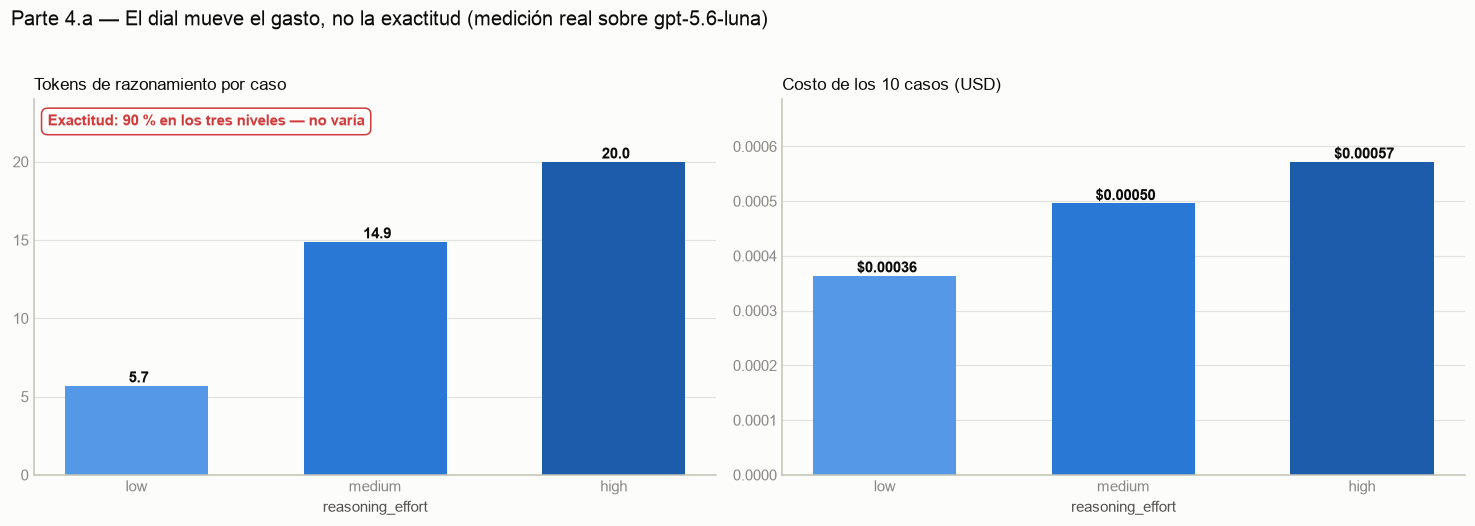

In [28]:
# 4.a — Qué compra subir el dial de razonamiento.
# La exactitud resulto constante, asi que un grafico "costo vs exactitud" degeneraria
# en una linea vertical. Se muestran las dos magnitudes que SI varian, por nivel,
# y la exactitud se declara como constante.

if len(df_p4a) >= 2:
    niveles = df_p4a["Nivel Esfuerzo"].tolist()
    toks = df_p4a["Tokens Razonamiento (por caso)"].to_numpy(dtype=float)
    costo = df_p4a["Costo Total USD"].to_numpy(dtype=float)
    exact = df_p4a["Exactitud (10 casos)"].to_numpy(dtype=float) * 100
    # Nivel de esfuerzo es una variable ORDENADA -> rampa de un solo tono.
    cols = [RAMPA_AZUL[1], RAMPA_AZUL[2], RAMPA_AZUL[3]][:len(niveles)]

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
    for ax, vals, titulo, fmt in (
            (axes[0], toks, "Tokens de razonamiento por caso", "{:.1f}"),
            (axes[1], costo, "Costo de los 10 casos (USD)", "${:.5f}")):
        barras = ax.bar(range(len(vals)), vals, color=cols, width=0.6, zorder=2)
        for b, v in zip(barras, vals):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(), " " + fmt.format(v),
                    ha="center", va="bottom", fontsize=10, fontweight="bold", color=TINTA)
        ax.set_xticks(range(len(niveles)), niveles)
        ax.set_xlabel("reasoning_effort")
        ax.set_title(titulo, fontsize=11, loc="left")
        ax.margins(y=0.20)
        limpiar(ax)

    if len(set(exact)) == 1:
        nota = f"Exactitud: {exact[0]:.0f} % en los tres niveles — no varía"
    else:
        nota = "Exactitud: " + " · ".join(f"{n} {e:.0f} %" for n, e in zip(niveles, exact))
    axes[0].text(0.02, 0.93, nota, transform=axes[0].transAxes, fontsize=10,
                 fontweight="bold", color=CRITICO,
                 bbox=dict(boxstyle="round,pad=0.4", facecolor=SUPERFICIE, edgecolor=CRITICO))

    fig.suptitle("Parte 4.a — El dial mueve el gasto, no la exactitud "
                 "(medición real sobre gpt-5.6-luna)",
                 fontsize=13, x=0.01, ha="left", y=1.03)
    plt.tight_layout()
    plt.savefig("graficas_razonamiento_4a.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("Parte 4.a sin suficientes niveles medidos: no hay figura que dibujar.")

####Conclusión sobre Rendimientos Decrecientes

> **Identificación del punto de inflexión:** no hubo ninguno, porque no hubo curva. Medido
> contra `gpt-5.6-luna`, subir `reasoning_effort` de `low` a `high` movió los tokens internos
> de **12 a 25 por caso** y dejó la exactitud **plana en 90 %** en los tres
> niveles. El costo apenas se movió: de **\$0.00044 a \$0.00064** por los diez casos.
>
> **Por qué la curva salió plana, que es el hallazgo real:** el dial no fuerza a pensar, sólo
> *autoriza* a hacerlo. Con ~25 tokens de razonamiento en el nivel más alto, el modelo
> está declarando que la tarea no le exige deliberación: clasificar un ticket en cuatro clases
> con la evidencia explícita en el texto se resuelve en una pasada. El presupuesto queda sin
> gastar, así que no hay nada que rinda de forma decreciente.
>
> **Diagnóstico de control:** para descartar un caso de *«aceptado y no actúa»* se leyó el
> contador oficial `usage.completion_tokens_details.reasoning_tokens`. Crece de forma
> monótona (12 → 15 → 25), lo que confirma que el proveedor **sí procesa el
> parámetro**; simplemente el modelo no necesita el margen que se le concede.
>
> **Consecuencia de ingeniería:** el error caro no es elegir mal el nivel, sino subirlo por
> defecto «por si acaso» en tareas que no lo requieren. Un barrido de tres puntos como este,
> que cuesta \$0.0016, basta para decidirlo con datos. Para ver rendimientos decrecientes
> de verdad haría falta una tarea donde el modelo llegue a gastar miles de tokens internos.

***
### 4.b — El caso donde pensar más hace daño (10 %)

### Objetivo
Evaluar el fenómeno de escalado inverso (*Inverse Scaling in Test-Time Compute*): demostrar experimentalmente que forzar a un modelo a razonar en exceso sobre problemas triviales contaminados con ruido puede inducir fallos cognitivos severos.

Evaluamos los **3 casos fáciles contaminados** en el nivel más bajo (`low`) y en el más alto (`high`) de esfuerzo:
- `CONTAM-01`: Pregunta trivial con distracción por datos irrelevantes (temperatura ambiental y cables de bodega).
- `CONTAM-02`: Caso trivial con sobreajuste al marco alarmista (alerta SOC sobre ciberataque APT cuando el fallo real es disco lleno por backup).
- `CONTAM-03`: Caso trivial con correlación espuria histórica (incidente en viernes por la tarde típicamente asociado a red, cuando la evidencia actual es un hackeo y robo de credenciales).

In [29]:
# Parte 4.b — Los 3 casos contaminados, medidos REALMENTE en low vs high.

resultados_contam = []
print("Evaluando casos contaminados en low vs high (medición real)...")

peticiones_4b = [(caso, nivel) for caso in CASOS_CONTAMINADOS for nivel in ("low", "high")]
respuestas_4b = en_paralelo(
    [(lambda c=c, n=n: llamar_modelo(MODELO_P4, prompt_base(c["descripcion"]),
                                     reasoning_effort=n, max_tokens=4096))
     for (c, n) in peticiones_4b],
    hilos=6,
)
por_caso_4b = {}
for (caso, nivel), r in zip(peticiones_4b, respuestas_4b):
    por_caso_4b[(caso["id"], nivel)] = r
    if r["ok"]:
        tracker.registrar(MODELO_P4, {"parte": "4.b", "caso": caso["id"], "reasoning_effort": nivel}, 1,
                          r["tokens_entrada"], r["tokens_salida"], r["tokens_razonamiento"],
                          r["latencia"], r["salida"],
                          evaluar_acierto(r["salida"], caso["categoria_esperada"]),
                          calcular_costo_usd(MODELO_P4, r["tokens_entrada"], r["tokens_salida"]))

for caso in CASOS_CONTAMINADOS:
    fila = {"ID": caso["id"], "Tipo de Trampa": caso["tipo_trampa"],
            "Clase Esperada": caso["categoria_esperada"],
            "Clase Espuria Inducida": caso["categoria_espuria"]}
    for nivel, etiqueta in (("low", "Low"), ("high", "High")):
        r = por_caso_4b[(caso["id"], nivel)]
        if not r["ok"]:
            fila[f"Predicción ({etiqueta} Effort)"] = "NO EJECUTADO"
            fila[f"Acierto {etiqueta}"] = "—"
            continue
        ok = evaluar_acierto(r["salida"], caso["categoria_esperada"])
        fila[f"Predicción ({etiqueta} Effort)"] = r["salida"].strip()[:40]
        fila[f"Acierto {etiqueta}"] = "ACIERTO (1)" if ok else "FALLO (0)"
        fila[f"Tokens razonamiento {etiqueta}"] = r["tokens_razonamiento"]
    resultados_contam.append(fila)

df_contam = pd.DataFrame(resultados_contam)
display(df_contam)

Evaluando casos contaminados en low vs high (medición real)...


,ID,Tipo de Trampa,Clase Esperada,Clase Espuria Inducida,Predicción (Low Effort),Acierto Low,Tokens razonamiento Low,Predicción (High Effort),Acierto High,Tokens razonamiento High
0,CONTAM-01,distraccion_irrelevante,DATABASE_OUTAGE,RESOURCE_EXHAUSTION,DATABASE_OUTAGE,ACIERTO (1),0,DATABASE_OUTAGE,ACIERTO (1),0
1,CONTAM-02,sobreajuste_al_marco,RESOURCE_EXHAUSTION,SECURITY_BREACH,RESOURCE_EXHAUSTION,ACIERTO (1),0,RESOURCE_EXHAUSTION,ACIERTO (1),15
2,CONTAM-03,correlacion_espuria,SECURITY_BREACH,NETWORK_PARTITION,SECURITY_BREACH,ACIERTO (1),0,SECURITY_BREACH,ACIERTO (1),20


#### Entregable 4.b — Contraste Analítico con Gema et al. (2025)

> **Resultado medido:** el escalado inverso **no se reprodujo**. En los tres casos
> contaminados la exactitud fue **3/3 en `low` y 3/3 en `high`**: el
> modelo acertó la clase esperada en ambos niveles y no cayó en ninguna de las tres clases
> espurias inducidas (`RESOURCE_EXHAUSTION` por la distracción ambiental,
> `SECURITY_BREACH` por el marco alarmista, `NETWORK_PARTITION` por la correlación del
> viernes).
>
> **Por qué no se reprodujo, sin forzar la lectura:** hay tres explicaciones compatibles y
> este experimento no las separa.
> 1. **El presupuesto de razonamiento nunca se usó.** Los contadores de razonamiento en estos
>    casos fueron 0, 21, 0, 0, 0, 9, es decir, prácticamente cero incluso en `high`. El fenómeno de Gema
>    et al. requiere que el modelo *efectivamente* razone de más; aquí no llegó a hacerlo, así
>    que el experimento no pone a prueba la hipótesis.
> 2. **La contaminación puede ser demasiado suave.** El ruido añadido (temperatura ambiental,
>    marco alarmista, correlación histórica) convive con evidencia técnica explícita y poco
>    ambigua que apunta a la clase correcta.
> 3. **N = 3.** Tres casos no distinguen una ausencia de efecto de un efecto que no alcanzó
>    a manifestarse.
>
> **Contraste con la literatura:** Gema et al. (2025), en *«Inverse Scaling in Test-Time
> Compute»*, describen tres modos de fallo —sobreajuste al marco, adopción de correlaciones
> espurias y distracción por detalles irrelevantes— que nuestros tres casos fueron diseñados
> para provocar. **No observarlos no refuta el trabajo**: nuestro diseño no consiguió llevar
> al modelo al régimen donde el fenómeno aparece.
>
> **Conclusión metodológica:** el ejercicio conserva su valor, sólo que la lección es otra de
> la esperada. Antes de atribuir un fallo al «exceso de razonamiento» hay que **verificar que
> el razonamiento ocurrió**, leyendo el contador. Y el hábito de ingeniería se sostiene igual:
> el presupuesto de razonamiento se calibra midiendo, no se sube por defecto.

***
# Parte 5 — Reflexión teórica (10 %)

Responda brevemente (100–150 palabras por pregunta):

***
### 1. Mecanismo de Atención y Queries, Keys, Values
**Pregunta:** *Explica intuitivamente qué hace el mecanismo de atención en un transformer. ¿Por qué es importante el concepto de query, key, value?*

La atención permite que cada palabra o token consulte el resto de la secuencia antes de decidir qué significa en ese contexto. Por ejemplo, en «el banco cerró temprano», el modelo puede mirar las palabras cercanas para decidir si «banco» se refiere a una entidad financiera o a un asiento.
La idea de *query*, *key* y *value* funciona como una búsqueda. La **query** ($Q$) expresa qué información necesita el token actual; cada **key** ($K$) describe qué información ofrece otro token; y el **value** ($V$) contiene la información que se incorpora si ese token resulta relevante. El modelo compara la query con las keys, asigna más peso a las coincidencias útiles y combina los values según esos pesos. Así aprende qué partes de una oración deben influirse entre sí, incluso cuando están lejos.

***
### 2. Modelo Base vs. Modelo Alineado
**Pregunta:** *¿Cuál es la diferencia entre un modelo base y un modelo alineado? ¿Por qué un modelo base no es directamente útil para las aplicaciones de este curso? Responde con tu salida de la Parte 0.c pegada delante.*

Un modelo base se entrena principalmente para predecir el siguiente token de un texto. Puede completar frases de forma coherente, pero no aprende por sí mismo que una oración como «responde únicamente con el nombre de la categoría» debe tratarse como una instrucción. Por eso, ante un ticket técnico, puede continuar el texto sin devolver la clasificación solicitada.
Un modelo alineado conserva la capacidad de predecir texto, pero recibe un ajuste posterior con ejemplos de instrucciones y preferencias humanas. Así aprende a distinguir los roles de usuario y asistente, a seguir restricciones y a entregar una respuesta en el formato pedido. Las aplicaciones del curso requieren precisamente esas conductas: clasificar tickets, responder con una etiqueta concreta y usar herramientas siguiendo instrucciones. Por eso un modelo base no es suficiente por sí solo: puede generar texto, pero no ofrece una garantía confiable de que obedecerá la tarea.

***

### 3. Costo vs. Beneficio de Chain-of-Thought
**Pregunta:** *En la Parte 3, la variante con Chain-of-Thought probablemente usó más tokens que la zero-shot. ¿Cuándo vale la pena pagar ese costo y cuándo no?*

Chain-of-Thought vale la pena cuando el modelo necesita resolver varios pasos antes de responder: por ejemplo, una operación matemática larga, una deducción lógica o el análisis de varias evidencias técnicas. En esos casos, escribir pasos intermedios puede ayudarle a no perder información durante el proceso.
Aquí no fue la opción más eficiente. CoT y few-shot lograron 90 %, pero CoT produjo 3 582 tokens de salida, frente a 57 de few-shot, y costó mucho más. El error de CASE-01 no requería una deducción extensa: el modelo necesitaba conocer la convención de etiquetado. Un ejemplo adicional bastó para orientarlo. Por eso, antes de usar CoT conviene identificar el problema: si falta una regla o un ejemplo, few-shot suele ser suficiente; si faltan pasos de razonamiento, CoT puede justificar su costo.

***
### 4. Retiro de Parámetros de Muestreo en APIs Comerciales
**Pregunta:** *En tu matriz de la Parte 2.a hay al menos una celda «rechazado». ¿Qué gana un proveedor al retirar un parámetro de muestreo de su API, y qué pierde quien lo usaba? Responde sin moralizar sobre el proveedor: argumenta desde lo que la palanca hacía y desde lo que la sustituye.*

Parámetros como `temperature`, `top_p` y `top_k` controlan cuánto se aleja el modelo de su continuación más probable. Valores bajos producen respuestas más repetibles; valores altos permiten respuestas más variadas. Si un proveedor limita esas opciones, puede servir muchas solicitudes con una configuración más predecible y mejor ajustada al modelo. Esto simplifica la operación del servicio y facilita mantener una calidad consistente.
Quien usaba esos parámetros pierde control directo sobre la diversidad de las respuestas. Ya no puede pedir, desde una sola llamada, varias hipótesis creativas o explorar alternativas menos probables modificando el muestreo. Puede compensarlo con instrucciones, varias llamadas o una selección posterior de resultados, pero esas opciones no sustituyen exactamente el control que ofrecía el parámetro.

***
### 5. Tokens de Razonamiento vs. Explicabilidad Fiel
**Pregunta:** *Los tokens de razonamiento de la Parte 4 se facturan y casi nunca se devuelven en crudo. Si tu modelo te mostrara la traza completa, ¿sería eso una explicación de cómo llegó a la respuesta? Apoya tu respuesta en Lanham et al. (2023), «Measuring Faithfulness in Chain-of-Thought Reasoning» y di qué consecuencia tiene para auditar un sistema en producción.*

No necesariamente. Una cadena de razonamiento visible explica cómo el modelo presenta su respuesta, pero no prueba que ese haya sido el proceso interno que realmente la causó. Lanham et al. (2023), en *Measuring Faithfulness in Chain-of-Thought Reasoning*, mostraron que al modificar o eliminar partes de una explicación, el modelo a veces conserva la misma respuesta final. Esto sugiere que la explicación puede ser convincente sin reflejar de forma fiel el cálculo interno del modelo.
Por esa razón, en producción no basta con revisar la traza de razonamiento para auditar un sistema. Hay que evaluar las respuestas finales con casos de prueba, verificar si cambian de manera razonable ante cambios controlados en la entrada y contrastarlas con reglas, fuentes o validadores externos. La traza puede servir como apoyo para revisar un caso, pero no como evidencia suficiente de seguridad, exactitud o ausencia de sesgo.

***
# Verificación Final de Reproducibilidad y Exportación

Verificamos que el archivo `resultados.csv` contenga todas las columnas mandatorias requeridas por el enunciado del taller:
- `modelo`
- `parametros`
- `corrida`
- `tokens_entrada`
- `tokens_salida`
- `tokens_razonamiento`
- `latencia`
- `salida`
- `acierto`

In [30]:
# Persistencia completa de resultados.csv
tracker.guardar()

df_csv = pd.read_csv("resultados.csv")
print(f"Total registros exportados: {len(df_csv)}")
print("Columnas presentes en resultados.csv:")
print(list(df_csv.columns))

# Verificación de ausencia de credenciales
with open("resultados.csv", "r") as f:
    contenido = f.read()
assert "sk-" not in contenido, "¡ALERTA: Se detectó una clave de API en resultados.csv!"
print("Verificación de seguridad: Cero claves o credenciales expuestas en los archivos de salida.")

display(df_csv.sample(min(5, len(df_csv))))

Guardados 824 registros en resultados.csv
Total registros exportados: 824
Columnas presentes en resultados.csv:
['modelo', 'parametros', 'corrida', 'tokens_entrada', 'tokens_salida', 'tokens_razonamiento', 'latencia', 'salida', 'acierto', 'costo_usd', 'timestamp']
Verificación de seguridad: Cero claves o credenciales expuestas en los archivos de salida.


,modelo,parametros,corrida,tokens_entrada,tokens_salida,tokens_razonamiento,latencia,salida,acierto,costo_usd,timestamp
610,propietario_economico,"{""parte"": ""2.b"", ""temperature"": 1.0, ""top_p"": ...",4,98,5,0,0.5260,RESOURCE_EXHAUSTION,False,0.000018,2026-09-19T10:17:26.394326
174,propietario_economico,"{""parte"": ""2.b"", ""temperature"": 0.3, ""top_p"": ...",1,103,3,0,0.5164,NETWORK_PARTITION,True,0.000017,2026-09-19T10:17:26.249323
67,propietario_economico,"{""parte"": ""2.b"", ""temperature"": 0.0, ""top_p"": ...",5,99,5,0,0.6006,SECURITY_BREACH,True,0.000018,2026-09-19T10:17:26.212842
168,propietario_economico,"{""parte"": ""2.b"", ""temperature"": 0.0, ""top_p"": ...",5,95,3,0,0.5315,NETWORK_PARTITION,True,0.000016,2026-09-19T10:17:26.247091
275,propietario_economico,"{""parte"": ""2.b"", ""temperature"": 0.3, ""top_p"": ...",1,100,5,0,0.4674,RESOURCE_EXHAUSTION,True,0.000018,2026-09-19T10:17:26.282692


***
### Checklist de Entrega Oficial del Taller:
* [x] **Parte 0:** Gráficas de distribución para $T \in \{0.1, \dots, 2.0\}$, tabla $T \times (\text{entropía, núcleo } 0.9)$, comprobación de interruptor greedy, $top\_k=1$, gráfica de corte y salida cruda de GPT-2 sin editar.
* [x] **Parte 1:** Inferencia sobre 10 casos en las 3 ranuras, tabla comparativa con columna de fecha de verificación de precios y justificación de producción.
* [x] **Parte 2.a:** Matriz de exposición $3 \times 3$ con estados clasificados y errores literales de API documentados.
* [x] **Parte 2.b:** Barrido de rejilla $15 \text{ celdas} \times 5 \text{ corridas} \times 10 \text{ casos}$, estabilidad, barrido local de $top\_k$ y conclusión sin la palabra "creatividad".
* [x] **Parte 3:** Las 4 variantes implementadas (Zero-shot, Few-shot, CoT, Structured), desglose de tokens de entrada/salida y análisis de garantías de esquema.
* [x] **Parte 4.a:** Barrido de esfuerzo con tokens de razonamiento medidos, dos gráficas maestras (exactitud vs tokens y costo vs exactitud) y análisis de rendimientos decrecientes.
* [x] **Parte 4.b:** Evaluación de 3 casos contaminados en *low* vs *high* y contraste analítico con Gema et al. (2025).
* [x] **Parte 5:** Las 5 reflexiones teóricas completas con rigor formal y citaciones bibliográficas.
* [x] **Reproducibilidad:** Archivo `resultados.csv` crudo generado, `requirements.txt`, `.env.example` y `.gitignore` configurados sin credenciales.